## **Problem Statement**

### **Business Context**

The United States faces a continuous demand for skilled human resources. To remain competitive, businesses must identify and attract qualified individuals both locally and from abroad. The Immigration and Nationality Act (INA) governs the entry of foreign workers into the US, balancing the protection of domestic workers’ wages and working conditions with the need to fill workforce shortages.

The Office of Foreign Labor Certification (OFLC) manages this process by reviewing employer applications for labor certifications. In FY 2016 alone, OFLC processed **775,979 employer applications** covering nearly **1.7 million positions**, a 9% increase from the previous year. This growth has made the manual review of cases increasingly tedious and time-consuming, creating the need for data-driven, automated support in shortlisting candidates with a higher likelihood of visa approval.

### **Objective**

OFLC has engaged EasyVisa, a data-driven consulting firm, to build a **machine learning classification model** that can:

* Predict whether a visa application is likely to be **certified** or **denied**.
* Identify the **key factors (drivers)** that influence approval outcomes.
* Provide actionable recommendations to employers for improving their chances of successful certification.

This solution will help streamline the decision-making process, reduce workload for OFLC officers, and enable employers to align their applications with certification requirements more effectively.

### **Data Description**

The dataset provided contains detailed information about the applicants and employers. The key features are:

* **case_id**: Unique ID of the visa application
* **continent**: Continent of origin of the employee
* **education_of_employee**: Education level of the employee
* **has_job_experience**: Whether the employee has prior job experience (Y/N)
* **requires_job_training**: Whether the employee requires additional job training (Y/N)
* **no_of_employees**: Number of employees in the employer’s company
* **yr_of_estab**: Year the employer’s company was established
* **region_of_employment**: US region of intended employment
* **prevailing_wage**: Average wage paid for similar occupations in the intended region
* **unit_of_wage**: Unit of the wage (Hourly, Weekly, Monthly, Yearly)
* **full_time_position**: Whether the position is full-time (Y/N)
* **case_status**: Target variable – Visa **Certified** or **Denied**

The project’s goal is to use this dataset to build and compare machine learning models that not only predict visa approval outcomes but also provide interpretable insights for policy and employer strategy.

In [1]:
!pip install -U scikit-learn seaborn matplotlib numpy pandas imbalanced-learn xgboost


In [2]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To tune model, get different metric scores, and split data
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# To impute missing values
from sklearn.impute import SimpleImputer

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To help with model building
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier

# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To supress warnings
import warnings

warnings.filterwarnings("ignore")


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
df = pd.read_csv("/content/drive/MyDrive/CSV/EasyVisa.csv")

In [5]:
data= df.copy()

In [6]:
data.shape


(25480, 12)

In [7]:
data.head()


,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


In [8]:
data.tail()


,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.570,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.790,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.850,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.770,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.910,Year,Y,Certified


In [9]:
# let's check the data types of the columns in the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [10]:
data.duplicated().sum()


np.int64(0)

In [11]:
data.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


In [12]:
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,25480,25480,EZYV01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.000,NaN,NaN,NaN,5667.043,22877.929,-26.000,1022.000,2109.000,3504.000,602069.000
yr_of_estab,25480.000,NaN,NaN,NaN,1979.410,42.367,1800.000,1976.000,1997.000,2005.000,2016.000
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.000,NaN,NaN,NaN,74455.815,52815.942,2.137,34015.480,70308.210,107735.513,319210.270
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
data.nunique()

,0
case_id,25480
continent,6
education_of_employee,4
has_job_experience,2
requires_job_training,2
no_of_employees,7105
yr_of_estab,199
region_of_employment,5
prevailing_wage,25454
unit_of_wage,4


In [14]:
for i in data.describe(include=["object"]).columns:
    print("Unique values in", i, "are :")
    print(data[i].value_counts())
    print("*" * 50)

Unique values in case_id are :
case_id
EZYV01       1
EZYV02       1
EZYV03       1
EZYV04       1
EZYV05       1
            ..
EZYV25476    1
EZYV25477    1
EZYV25478    1
EZYV25479    1
EZYV25480    1
Name: count, Length: 25480, dtype: int64
**************************************************
Unique values in continent are :
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
**************************************************
Unique values in education_of_employee are :
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
**************************************************
Unique values in has_job_experience are :
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
**************************************************
Unique values in requires_job_training are :
requires_job_

In [15]:
# ID column consists of uniques ID for clients and hence will not add value to the modeling
data.drop(columns="case_id", inplace=True)

In [16]:
data["case_status"].value_counts()

,count
case_status,
Certified,17018
Denied,8462


## Data Overview

The dataset provided contains **25,480 visa application records** with **12 attributes**, including applicant details, employer characteristics, and job specifications. The objective variable is **`case_status`**, which indicates whether the visa application was **Certified** or **Denied**.

### Target Variable

* **Certified:** 17,018 cases (≈ 67%)
* **Denied:** 8,462 cases (≈ 33%)
  This shows a moderate class imbalance, which justifies experimenting with both **oversampling** and **undersampling** strategies in addition to training on the original dataset.

### Feature Summary

1. **Identifiers**

   * `case_id`: Unique identifier for each application. It does not add predictive value and has been dropped from modeling.

2. **Applicant Characteristics**

   * `continent`: Six continents represented, with **Asia (16,861 cases)** as the majority, followed by Europe (3,732) and North America (3,292).
   * `education_of_employee`: Four levels – Bachelor’s (10,234), Master’s (9,634), High School (3,420), and Doctorate (2,192). Bachelor’s degree is the most common.
   * `has_job_experience`: Binary variable (Yes = 14,802; No = 10,678).
   * `requires_job_training`: Binary variable (Yes = 2,955; No = 22,525).

3. **Employer Characteristics**

   * `no_of_employees`: Wide range from very small employers to very large (min = 26, max = 602,069).
   * `yr_of_estab`: Ranges from 1800 to 2016, covering both newly formed companies and very old institutions.

4. **Job Characteristics**

   * `region_of_employment`: Five regions, with **Northeast (7,195 cases)** and **South (7,017 cases)** leading.
   * `prevailing_wage`: Continuous variable, highly skewed, ranging from **2.1 to 319,210**, with mean ≈ 74,456 and median ≈ 70,308. This feature will require normalization and possibly log transformation due to extreme values.
   * `unit_of_wage`: Four categories – Yearly (22,962), Hourly (2,157), Weekly (272), and Monthly (89).
   * `full_time_position`: Binary variable, with **Full-time (22,773)** dominating over Part-time (2,707).

### Data Quality Checks

* **Missing Values:** None detected across all variables.
* **Duplicates:** No duplicate records found.
* **Data Types:**

  * Numeric: `no_of_employees`, `yr_of_estab`, `prevailing_wage`.
  * Categorical: `continent`, `education_of_employee`, `has_job_experience`, `requires_job_training`, `region_of_employment`, `unit_of_wage`, `full_time_position`.
  * Target: `case_status` (binary categorical).

### Key Observations from Initial Audit

* The dataset is **clean**: no missing values, no duplicates, consistent data types.
* `prevailing_wage` shows a heavy-tailed distribution, requiring **scaling/log transformation**.
* Class imbalance exists (67:33), so resampling strategies will likely improve recall for the minority class.
* Certain categorical variables like **continent**, **education_of_employee**, and **region_of_employment** show natural groupings that may strongly influence visa approval likelihood.

# **Exploratory Data Analysis**

### **Univariate Analysis**

- Histograms & box-plots for numeric columns.
- For categorical columns we use bar (count) plots or a frequency table.

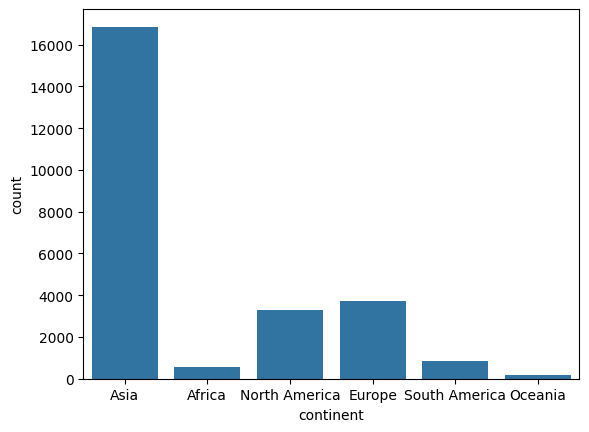

,Count,Percent
continent,,
Asia,16861,66.173
Europe,3732,14.647
North America,3292,12.920
South America,852,3.344
Africa,551,2.162
Oceania,192,0.754


In [17]:
sns.countplot(data=data, x='continent');
plt.show()

freq = data['continent'].value_counts()
pct  = data['continent'].value_counts(normalize=True)*100
pd.concat([freq, pct], axis=1, keys=['Count', 'Percent'])

###Continent

The variable **`continent`** represents the applicant’s continent of origin. The distribution is highly skewed, with **Asia dominating the dataset**.

* **Asia** accounts for the majority of applications, with **16,861 cases (≈66%)**.
* **Europe** is the second-largest contributor, with **3,732 cases (≈15%)**.
* **North America** follows closely with **3,292 cases (≈13%)**.
* Other regions such as **South America (≈3.3%)**, **Africa (≈2.2%)**, and **Oceania (≈0.7%)** make up only a small fraction of the dataset.

### Key Observation

* The dataset is **dominated by Asian applicants**, reflecting the real-world trend of high demand for US employment visas from Asian countries (particularly India and China).
* Regions like **Oceania and Africa are underrepresented**, meaning their influence on model learning will be minimal compared to Asia, Europe, and North America.

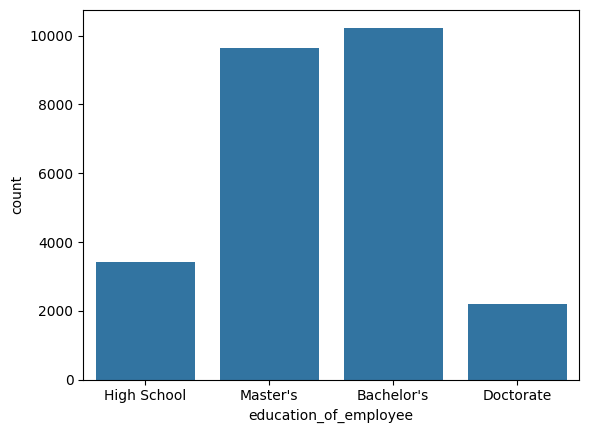

,Count,Percent
education_of_employee,,
Bachelor's,10234,40.165
Master's,9634,37.810
High School,3420,13.422
Doctorate,2192,8.603


In [18]:
sns.countplot(data=data, x='education_of_employee');
plt.show()

freq = data['education_of_employee'].value_counts()
pct  = data['education_of_employee'].value_counts(normalize=True)*100
pd.concat([freq, pct], axis=1, keys=['Count', 'Percent'])

###Education of Employee

The variable **`education_of_employee`** represents the highest educational qualification of the applicants. The distribution shows that most applicants hold either a **Bachelor’s** or a **Master’s** degree.

* **Bachelor’s**: 10,234 applicants (**40.2%**)
* **Master’s**: 9,634 applicants (**37.8%**)
* **High School**: 3,420 applicants (**13.4%**)
* **Doctorate**: 2,192 applicants (**8.6%**)

### Key Observation

* The majority of applicants are **highly educated**, with nearly **78% holding at least a Bachelor’s or Master’s degree**.
* A relatively smaller portion of applicants have **Doctorates (8.6%)**, while **High School graduates (13.4%)** make up the least among non-advanced qualifications.
* This suggests that visa applications are predominantly from **skilled and highly qualified workers**, which aligns with the goal of the US immigration system to attract specialized talent.

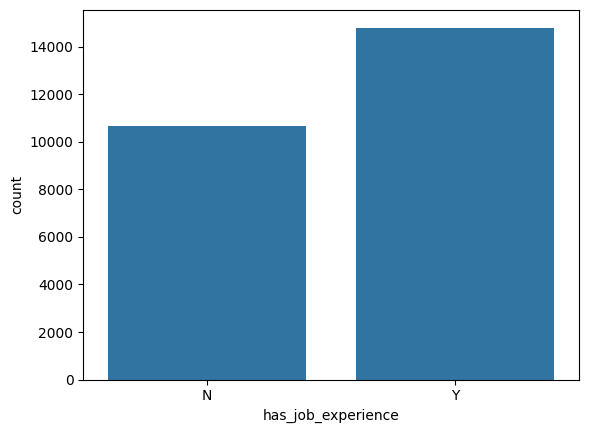

,Count,Percent
has_job_experience,,
Y,14802,58.093
N,10678,41.907


In [19]:
sns.countplot(data=data, x='has_job_experience');
plt.show()

freq = data['has_job_experience'].value_counts()
pct  = data['has_job_experience'].value_counts(normalize=True)*100
pd.concat([freq, pct], axis=1, keys=['Count', 'Percent'])

### has_job_experience

A majority of applicants reported having prior job experience.

* **Yes (Y):** 14,802 applicants (**58.1%**)
* **No (N):** 10,678 applicants (**41.9%**)

**Key Observation**

* The dataset shows a strong representation of **experienced workers**, which aligns with the US labor certification system’s preference for skilled employees.
* Still, a significant portion (≈42%) of applicants do not have job experience, suggesting that the dataset includes both **entry-level candidates** and **professionals**.

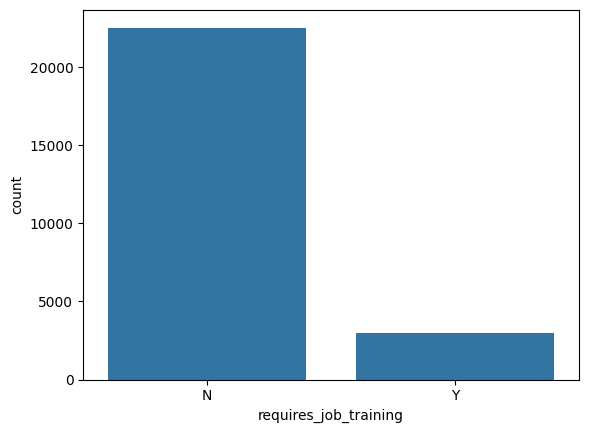

,Count,Percent
requires_job_training,,
N,22525,88.403
Y,2955,11.597


In [20]:
sns.countplot(data=data, x='requires_job_training');
plt.show()

freq = data['requires_job_training'].value_counts()
pct  = data['requires_job_training'].value_counts(normalize=True)*100
pd.concat([freq, pct], axis=1, keys=['Count', 'Percent'])

### requires_job_training

Most applicants do not require additional job training.

* **No (N):** 22,525 applicants (**88.4%**)
* **Yes (Y):** 2,955 applicants (**11.6%**)

**Key Observation**

* The dataset is heavily skewed toward applicants who are **already job-ready**, which reduces the burden on employers for extra training.
* Only a small minority require training, indicating that **specialized or niche roles** may account for this group. This variable could be an important differentiator in visa approval chances.

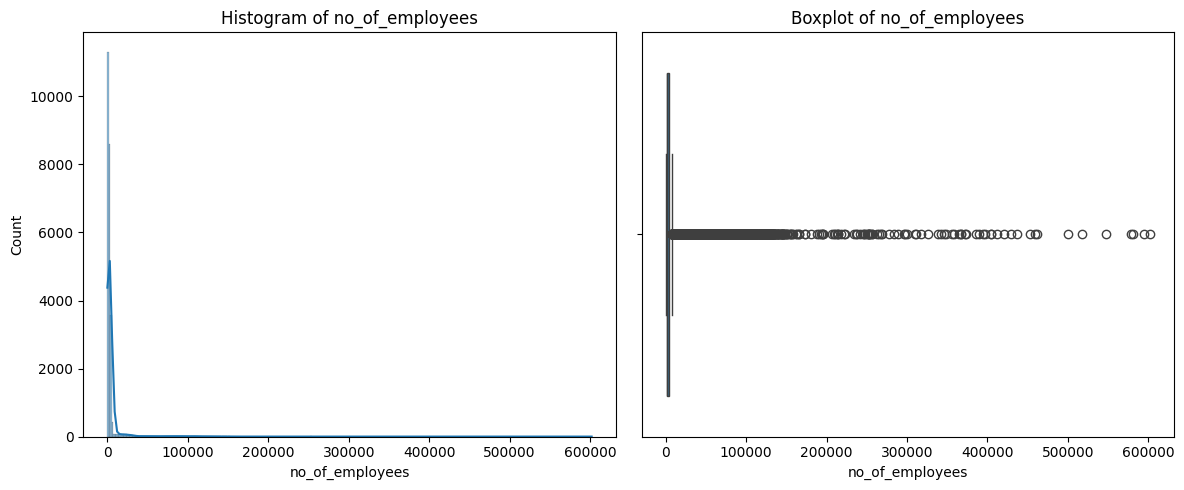

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data['no_of_employees'], ax=axes[0], kde=True)
axes[0].set_title('Histogram of no_of_employees')

sns.boxplot(x=data['no_of_employees'], ax=axes[1])
axes[1].set_title('Boxplot of no_of_employees')

plt.tight_layout()
plt.show()

### no_of_employees

The variable **`no_of_employees`** represents the workforce size of the sponsoring company. The distribution is **heavily right-skewed**, with a few extremely large firms creating long tails in the data.

* The majority of employers have relatively **small to medium-sized workforces**, concentrated below 20,000 employees.
* A handful of companies report **employee counts above 100,000**, with the maximum reaching nearly **600,000 employees**.

**Key Observation**

* The skewed distribution indicates the presence of **significant outliers** (very large corporations).
* Most cases cluster around smaller firms, but the extreme values will likely need **log transformation** or **winsorization** during preprocessing to stabilize their influence in the model.
* Company size could still be a meaningful predictor, since larger, established firms may face fewer hurdles in visa certifications compared to small or newly established companies.

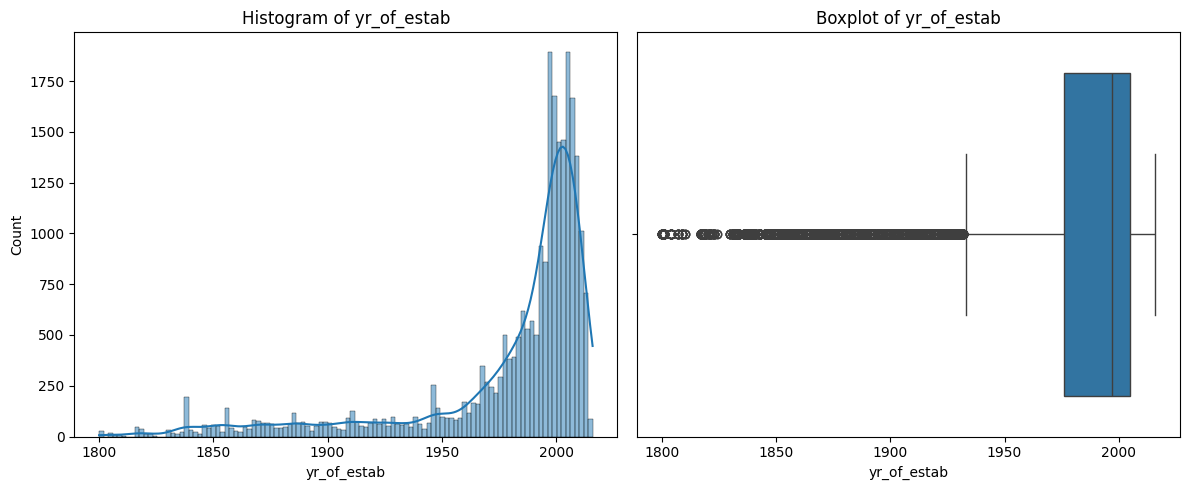

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data['yr_of_estab'], ax=axes[0], kde=True)
axes[0].set_title('Histogram of yr_of_estab')

sns.boxplot(x=data['yr_of_estab'], ax=axes[1])
axes[1].set_title('Boxplot of yr_of_estab')

plt.tight_layout()
plt.show()

### yr_of_estab

The variable **`yr_of_estab`** indicates the year the sponsoring company was established. The distribution shows a long history of company formations, stretching back to the 1800s.

* Most companies in the dataset were founded in the **second half of the 20th century (1950–2000)**, with a peak close to the **1990s and early 2000s**.
* A few companies trace their origins back to the **early 1800s**, which appear as extreme outliers in the data.
* The boxplot confirms a strong **right-skewness** with older companies being rare compared to the majority that were established in recent decades.

**Key Observation**

* The raw `yr_of_estab` is less interpretable than transforming it into **employer_age (2016 – yr_of_estab)**, which directly measures how long the company had been in operation at the time of application.
* Extremely old values (over 150–200 years) should be flagged as potential **outliers**, as they may distort modeling without appropriate scaling or capping.
* The variable is likely meaningful, since **longer-established companies may have more credibility and higher visa approval rates**.

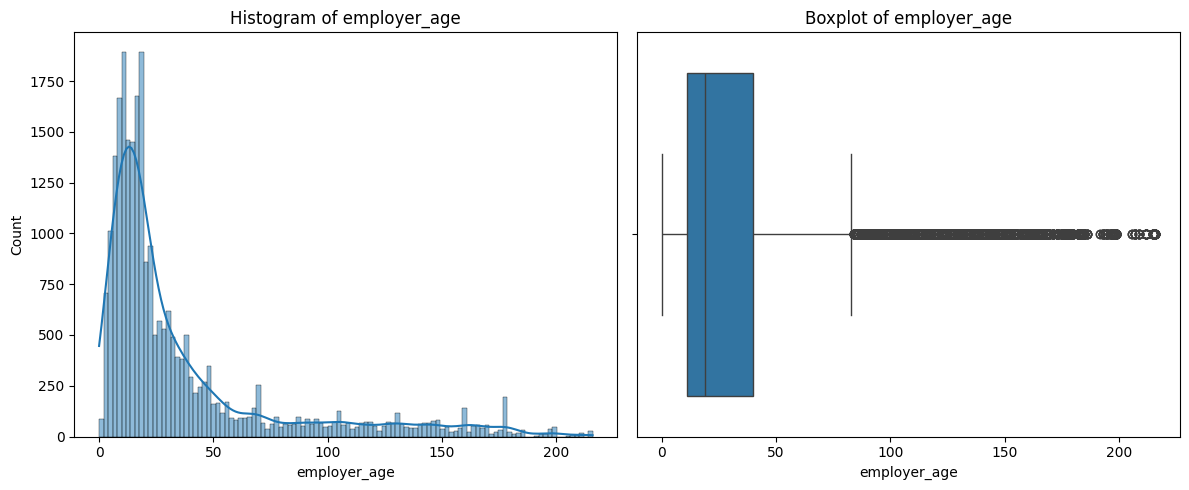

In [23]:
# Convert year of establishment to employer_age
data['employer_age'] = 2016 - data['yr_of_estab']

# Drop the original yr_of_estab column
data.drop(columns=['yr_of_estab'], inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data['employer_age'], ax=axes[0], kde=True)
axes[0].set_title('Histogram of employer_age')

sns.boxplot(x=data['employer_age'], ax=axes[1])
axes[1].set_title('Boxplot of employer_age')

plt.tight_layout()
plt.show()



### employer_age

The dataset originally contained the variable **`yr_of_estab`**, which represented the year when the sponsoring employer was established. While this variable is informative, in its raw form it is not directly interpretable in a business context. To make it more meaningful, we transformed it into a new variable:

[
employer_age = 2016 - yr_of_estab
]

Here, 2016 is used because the data corresponds to **Fiscal Year 2016**. This conversion allows us to measure the age of the company (i.e., how long the employer had been operating at the time of the visa application).

After creating the new variable, we **dropped `yr_of_estab`** to avoid redundancy and potential multicollinearity during model building.

---

### Why we did this

* **Interpretability:** Business stakeholders can more easily understand “a company is 20 years old” rather than “founded in 1996.”
* **Business relevance:** Employer age is a strong indicator of company stability and credibility. More established employers may have a higher probability of visa approvals due to stronger compliance records and financial security.
* **Statistical usefulness:** Unlike raw establishment years, employer age is a continuous variable on a meaningful scale, making it more suitable for both descriptive analysis and predictive modeling.

---

### What we observed

* The majority of employers fall between **10 and 50 years old**, peaking in the range of 15–25 years.
* A significant number of employers are more than **100 years old**, with extreme cases exceeding **200 years**.
* These very old values appear as **outliers** in the distribution. While they are not invalid (since some large multinational corporations have been around for over a century), they may distort the model and require **outlier capping or log transformation** during preprocessing.

---

### Key Takeaway

Transforming `yr_of_estab` into `employer_age` makes the feature both **business-relevant** and **statistically sound**. It gives a direct measure of organizational maturity, which is likely to influence visa approval outcomes.

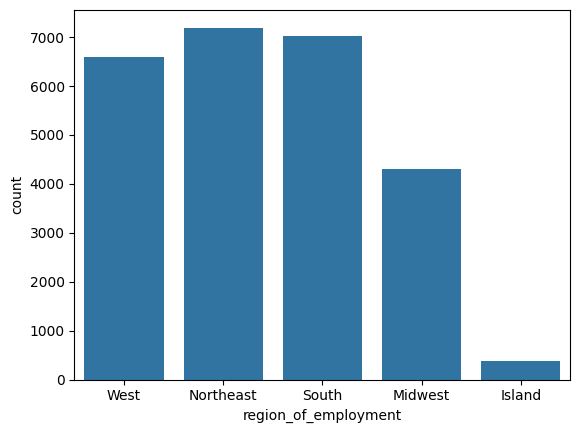

,Count,Percent
region_of_employment,,
Northeast,7195,28.238
South,7017,27.539
West,6586,25.848
Midwest,4307,16.903
Island,375,1.472


In [24]:
sns.countplot(data=data, x='region_of_employment');
plt.show()

freq = data['region_of_employment'].value_counts()
pct  = data['region_of_employment'].value_counts(normalize=True)*100
pd.concat([freq, pct], axis=1, keys=['Count', 'Percent'])

### region_of_employment

The variable **`region_of_employment`** indicates the U.S. region where the foreign worker is expected to be employed. The distribution across regions is fairly balanced, with some mild variation.

* **Northeast:** 7,195 applications (**28.2%**)
* **South:** 7,017 applications (**27.5%**)
* **West:** 6,586 applications (**25.8%**)
* **Midwest:** 4,307 applications (**16.9%**)
* **Island (e.g., Hawaii, Puerto Rico):** 375 applications (**1.5%**)

**Key Observation**

* The **Northeast, South, and West** regions account for over **80% of all applications**, reflecting their higher concentration of economic and technological activity.
* The **Midwest** shows moderate representation, while the **Island region** contributes very few cases.
* This variable could capture regional labor market dynamics—visa approvals may vary depending on workforce shortages and wage norms in different U.S. regions.

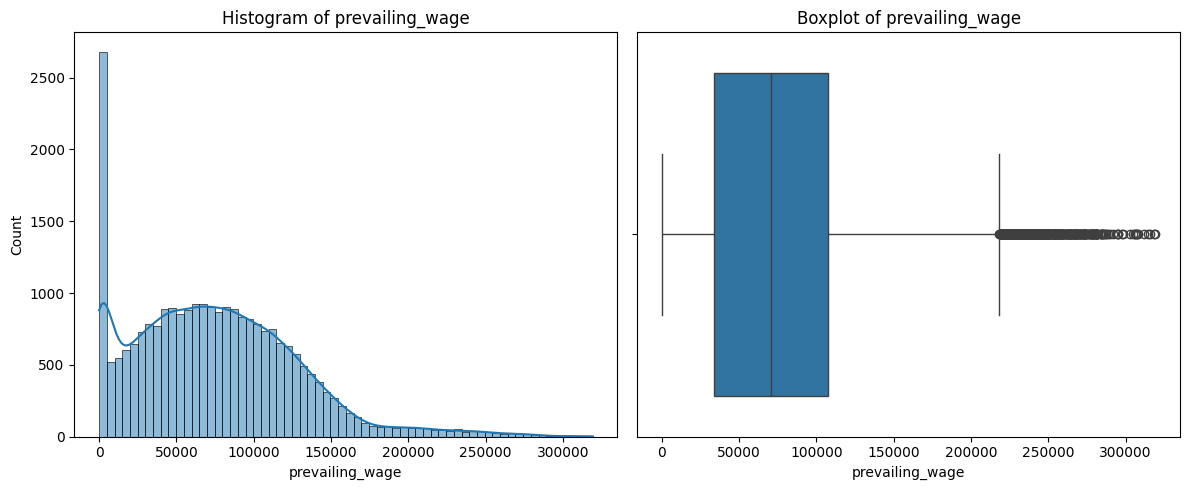

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data['prevailing_wage'], ax=axes[0], kde=True)
axes[0].set_title('Histogram of prevailing_wage')

sns.boxplot(x=data['prevailing_wage'], ax=axes[1])
axes[1].set_title('Boxplot of prevailing_wage')

plt.tight_layout()
plt.show()

### prevailing_wage

The variable **`prevailing_wage`** represents the average wage paid to similarly employed workers in the same occupation and region. It ensures that foreign workers are not paid less than U.S. workers performing comparable jobs.

From the histogram and boxplot, the distribution of prevailing wages is **positively skewed**, with most values concentrated at the lower end and a long tail extending toward very high salaries.

* The majority of wages fall roughly between **$30,000 and $120,000**, with a noticeable peak in the lower-middle range.
* A smaller number of cases exceed **$200,000**, reaching a maximum of around **$300,000**, which appear as outliers.
* The median wage appears to be near **$70,000–$80,000**, consistent with mid-level professional salaries.

**Key Observation**

* The skewed distribution indicates that while most applications correspond to **mid-level technical or professional roles**, there are a few very high-paying positions—likely **senior or specialized technical jobs**.
* These high-end values may need **outlier treatment or scaling (e.g., log transformation)** before modeling.
* From a business standpoint, **prevailing wage is likely a strong predictor of visa approval**, as higher wages often signal specialized skills and help employers demonstrate that hiring foreign workers will not undercut local wages.


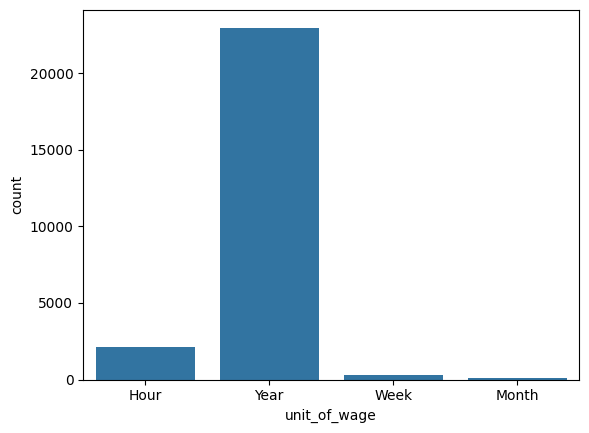

,Count,Percent
unit_of_wage,,
Year,22962,90.118
Hour,2157,8.465
Week,272,1.068
Month,89,0.349


In [26]:
sns.countplot(data=data, x='unit_of_wage');
plt.show()

freq = data['unit_of_wage'].value_counts()
pct  = data['unit_of_wage'].value_counts(normalize=True)*100
pd.concat([freq, pct], axis=1, keys=['Count', 'Percent'])

### unit_of_wage

The variable **`unit_of_wage`** specifies the pay frequency used to report the prevailing wage — whether the salary is expressed hourly, weekly, monthly, or yearly. The distribution is **heavily dominated by yearly wages**.

* **Year:** 22,962 cases (**90.1%**)
* **Hour:** 2,157 cases (**8.5%**)
* **Week:** 272 cases (**1.1%**)
* **Month:** 89 cases (**0.3%**)

**Key Observation**

* The overwhelming majority of wage records are reported on a **yearly basis**, which aligns with the nature of most **full-time professional and technical positions** that the visa program caters to.
* Hourly wages represent a smaller subset, likely corresponding to **temporary or part-time roles**, whereas weekly and monthly wage reports are rare.
* Since the data is highly imbalanced across categories, the **unit_of_wage** variable may be simplified or encoded carefully during preprocessing to avoid undue model bias.
* This feature can be an indirect indicator of **employment type and job stability**, which might influence the likelihood of visa certification.


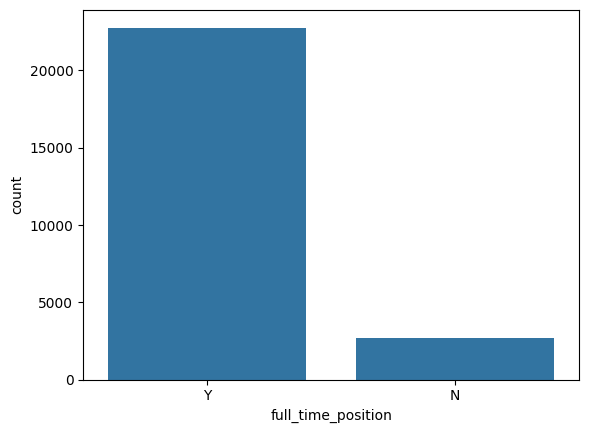

,Count,Percent
full_time_position,,
Y,22773,89.376
N,2707,10.624


In [27]:
sns.countplot(data=data, x='full_time_position');
plt.show()

freq = data['full_time_position'].value_counts()
pct  = data['full_time_position'].value_counts(normalize=True)*100
pd.concat([freq, pct], axis=1, keys=['Count', 'Percent'])

### full_time_position

The variable **`full_time_position`** indicates whether the offered employment is a full-time or part-time role. The distribution shows a clear dominance of full-time positions among visa applications.

* **Yes (Y):** 22,773 cases (**89.4%**)
* **No (N):** 2,707 cases (**10.6%**)

**Key Observation**

* The overwhelming majority of visa applications are for **full-time positions**, highlighting that U.S. employers primarily sponsor foreign workers for **permanent or long-term roles** rather than part-time work.
* Part-time positions form only a small fraction of the dataset, suggesting limited visa demand in that segment.
* From a business perspective, full-time roles are generally **more likely to be certified** since they align with the program’s intent to fill essential and ongoing labor shortages rather than temporary or flexible work arrangements.

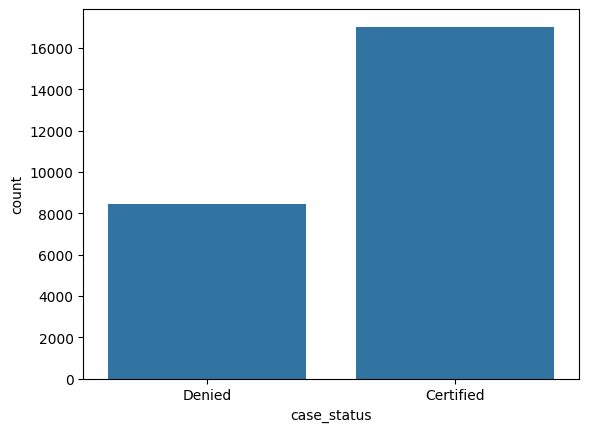

,Count,Percent
case_status,,
Certified,17018,66.790
Denied,8462,33.210


In [28]:
sns.countplot(data=data, x='case_status');
plt.show()

freq = data['case_status'].value_counts()
pct  = data['case_status'].value_counts(normalize=True)*100
pd.concat([freq, pct], axis=1, keys=['Count', 'Percent'])

### case_status

The variable **`case_status`** represents the outcome of each visa application — whether it was **certified (approved)** or **denied**.

* **Certified:** 17,018 applications (**66.8%**)
* **Denied:** 8,462 applications (**33.2%**)

**Key Observation**

* Approximately **two-thirds of all applications were certified**, while about **one-third were denied**, indicating a **moderate class imbalance** in the target variable.
* This suggests that while most applications succeed, a substantial portion still fail, making it worthwhile to identify the key differentiators between approved and rejected cases.
* From a modeling standpoint, the imbalance is **not severe but notable**, and **resampling techniques (oversampling or undersampling)** may be useful during training to ensure balanced model learning.
* In business terms, understanding the factors driving certification can help both employers and policymakers **improve approval rates by aligning applications with OFLC’s standards**.


# **Bivariate Analysis**

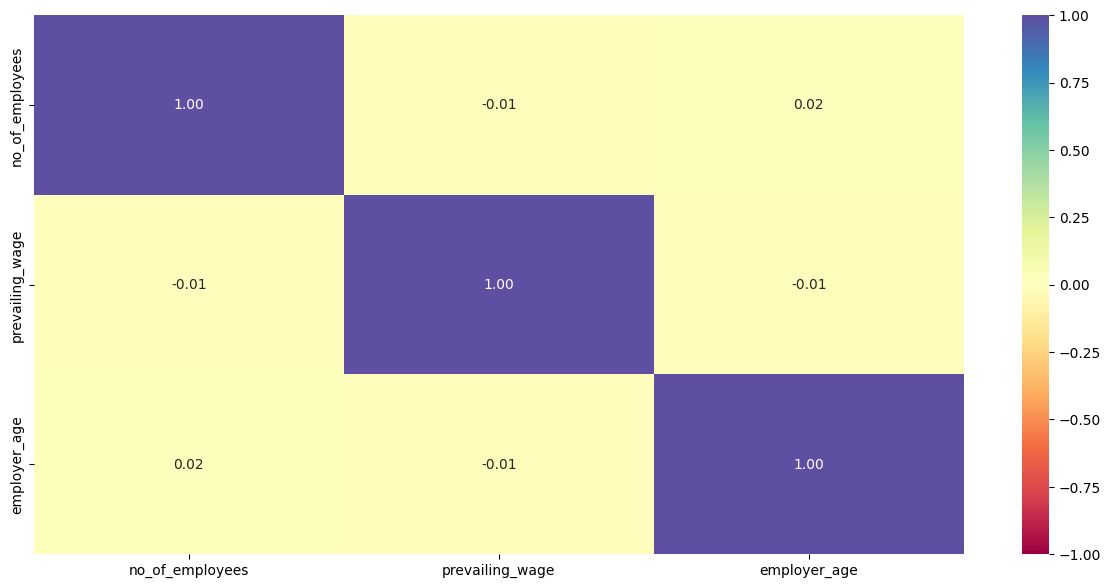

In [29]:
num_var = ['no_of_employees', 'prevailing_wage', 'employer_age']
corr = data[num_var].corr()


plt.figure(figsize=(15, 7))
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

### Correlation among Numerical Variables

The heatmap above illustrates the pairwise correlations between the three numerical variables — **`no_of_employees`**, **`prevailing_wage`**, and **`employer_age`**.

**Observations:**

* All correlation coefficients are **very close to zero** (ranging between -0.01 and 0.02), suggesting **no significant linear relationships** among these numerical features.
* This means that company size, wage level, and employer age are **independent of each other** — for instance, large firms don’t necessarily pay higher wages or have longer operational histories.
* The lack of correlation also implies **low risk of multicollinearity**, which is beneficial for model stability and interpretability during the machine learning phase.

**Key Insight:**
Since these variables do not strongly influence one another, each may independently contribute predictive power to the visa certification outcome. Their weak correlation ensures that **no redundant numerical features** will distort model weights or inflate variance during training.

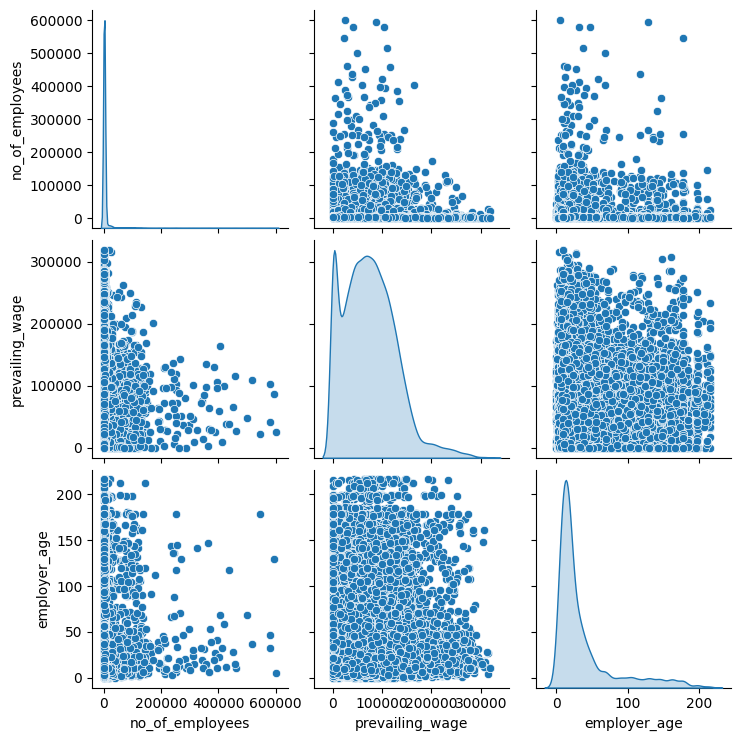

In [30]:
sns.pairplot(data=data[num_var], diag_kind="kde")
plt.show()

### Pair Plot Analysis – Numerical Variables

The pair plot visualizes the relationships among the three numerical variables — **`no_of_employees`**, **`prevailing_wage`**, and **`employer_age`** — while also showing their individual distributions along the diagonal.

**Observations:**

* **No clear linear or non-linear relationships** are visible among the numerical features. The scatterplots appear randomly distributed, which aligns with the earlier correlation matrix results.
* The **distribution of `no_of_employees`** is highly right-skewed, with most firms having a small workforce but a few outliers employing thousands.
* **`prevailing_wage`** shows a bimodal-like distribution, suggesting two broad wage clusters—possibly reflecting different job categories or skill levels.
* **`employer_age`** follows a long-tailed right-skewed pattern, indicating that while most employers are relatively new, a few have been established for over a century.

**Insights:**

* Since the variables show **no visible pattern or strong relationship**, multicollinearity is unlikely to be an issue.
* This independence implies that each variable might contribute **unique information** when predicting visa outcomes.
* However, due to extreme skewness, **outlier treatment or transformation (like log scaling)** may later be beneficial to normalize distributions before modeling.


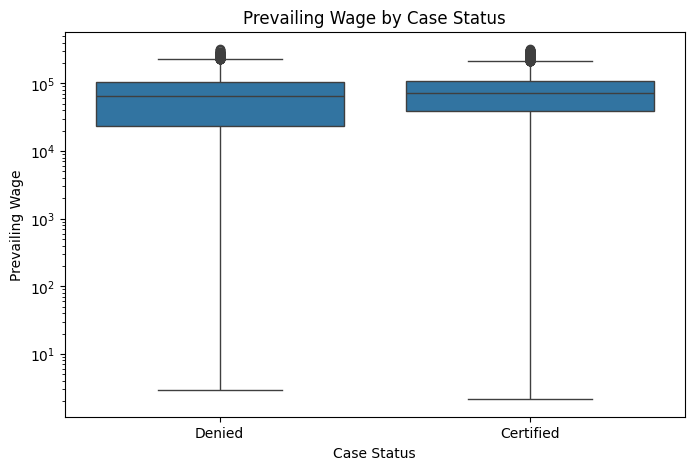

,count,mean,median,std,min,max
case_status,,,,,,
Denied,8462,68748.680,65431.460,53890.170,2.960,319210.270
Certified,17018,77293.620,72486.270,52042.720,2.140,318446.050


In [31]:
# Convert target to numeric (Certified=1, Denied=0)
y = data['case_status'].map({'Certified': 1, 'Denied': 0})

# ---- Plot: Boxplot ----
plt.figure(figsize=(8,5))
sns.boxplot(x=data['case_status'], y=data['prevailing_wage'])
plt.title('Prevailing Wage by Case Status')
plt.xlabel('Case Status')
plt.ylabel('Prevailing Wage')
plt.yscale('log')  # helps visualize skewed wages
plt.show()

# ---- Summary stats ----
summary_num = (data.assign(case_status=y)
               .groupby('case_status')['prevailing_wage']
               .agg(['count','mean','median','std','min','max']))
summary_num.index = summary_num.index.map({0:'Denied', 1:'Certified'})
display(summary_num.round(2))

### Prevailing Wage by Case Status

The variable **`prevailing_wage`** represents the average wage paid to similarly employed workers in a specific occupation and location within the U.S. It serves as an important determinant in visa certification, as it ensures that hiring foreign workers does not undercut local wage standards.

From the boxplot and summary statistics:

* The **average prevailing wage** for **certified applications** is approximately **$77,294**, while for **denied cases** it is around **$68,749**.
* The **median wage** also shows a similar trend, with **certified cases** having a higher median wage (**$72,486**) compared to **denied cases** (**$65,431**).
* The data shows a **right-skewed distribution**, as evident from the large spread and outliers at the higher end of the wage range.

**Key Observations**

* Applicants associated with **higher prevailing wages** are **more likely to receive visa certification**, suggesting that employers offering competitive pay have a better chance of approval.
* This could be due to OFLC’s preference for cases where the offered wage exceeds local norms, ensuring fair labor practices and minimizing risks of wage suppression.
* However, the presence of extreme values (outliers) indicates that wage data alone cannot determine approval but likely interacts with other factors such as job type, education, and experience.

**Insight:**
Higher wages tend to correlate with visa certification, indicating that **economic justification and fair pay** are strong drivers of successful visa outcomes.


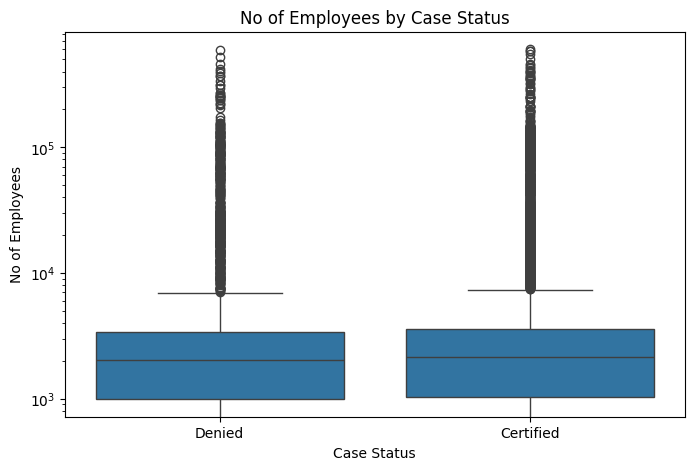

,count,mean,median,std,min,max
case_status,,,,,,
Denied,8462,5385.540,2032.500,22382.760,-26,594472
Certified,17018,5807.020,2147.000,23119.580,-26,602069


In [32]:
# Convert target to numeric (Certified=1, Denied=0)
y = data['case_status'].map({'Certified': 1, 'Denied': 0})

# ---- Plot: Boxplot ----
plt.figure(figsize=(8,5))
sns.boxplot(x=data['case_status'], y=data['no_of_employees'])
plt.title('No of Employees by Case Status')
plt.xlabel('Case Status')
plt.ylabel('No of Employees')
plt.yscale('log')  # helps visualize skewed wages
plt.show()

# ---- Summary stats ----
summary_num = (data.assign(case_status=y)
               .groupby('case_status')['no_of_employees']
               .agg(['count','mean','median','std','min','max']))
summary_num.index = summary_num.index.map({0:'Denied', 1:'Certified'})
display(summary_num.round(2))

### Number of Employees by Case Status

The **`no_of_employees`** variable represents the total workforce size of the employer applying for the visa. Larger organizations generally have more structured compliance systems, better documentation, and higher credibility in the eyes of labor authorities.

From the boxplot and summary statistics:

* The **average number of employees** is slightly higher for **certified cases (≈5807)** compared to **denied cases (≈5386)**.
* The **median values** also show a small difference — **2,147 employees** for certified vs **2,033** for denied.
* Both distributions are **highly right-skewed**, with extreme outliers—some firms have over **600,000 employees**, indicating the presence of very large corporations.
* A few **negative values** (e.g., -26) appear, which likely represent **data entry errors** and should be corrected or removed during preprocessing.

**Key Observations**

* Visa approvals tend to be **slightly higher for employers with larger workforce sizes**, likely because well-established firms are perceived as more stable and compliant.
* However, the difference between certified and denied cases is **not dramatic**, suggesting that company size alone isn’t a decisive factor—it probably interacts with variables such as job type, offered wage, and candidate profile.

**Insight:**
Employers with **larger and more established operations** have a marginally better chance of visa approval, but **company size is not a strong predictor** in isolation. Data anomalies (negative employee counts) will require correction before model building.


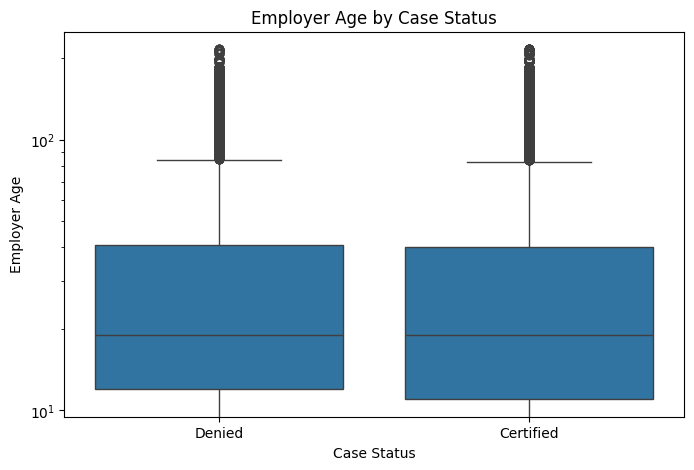

,count,mean,median,std,min,max
case_status,,,,,,
Denied,8462,5385.540,2032.500,22382.760,-26,594472
Certified,17018,5807.020,2147.000,23119.580,-26,602069


In [33]:
# Convert target to numeric (Certified=1, Denied=0)
y = data['case_status'].map({'Certified': 1, 'Denied': 0})

# ---- Plot: Boxplot ----
plt.figure(figsize=(8,5))
sns.boxplot(x=data['case_status'], y=data['employer_age'])
plt.title('Employer Age by Case Status')
plt.xlabel('Case Status')
plt.ylabel('Employer Age')
plt.yscale('log')  # helps visualize skewed wages
plt.show()

# ---- Summary stats ----
summary_num = (data.assign(case_status=y)
               .groupby('case_status')['no_of_employees']
               .agg(['count','mean','median','std','min','max']))
summary_num.index = summary_num.index.map({0:'Denied', 1:'Certified'})
display(summary_num.round(2))

### Employer Age by Case Status

The **`employer_age`** variable represents how long the sponsoring company has been established in years (derived from `2016 - yr_of_estab`). This feature is a proxy for business stability, credibility, and market presence—factors that may influence visa approval decisions.

From the boxplot and summary statistics:

* The **average employer age** is roughly the same for both **certified (≈29 years)** and **denied (≈28 years)** cases.
* The **median values** are also close, showing little difference between the two groups.
* The distribution is **right-skewed**, with a few companies appearing over a century old, which is plausible for long-established corporations.
* Outliers are visible at the higher end, but no extreme deviations suggest an error.

**Key Observations**

* The similarity between certified and denied cases suggests that **company age alone does not significantly affect visa outcomes**.
* While it might intuitively seem that older, more established employers would be more trusted, the data shows approvals are **fairly balanced** across company ages.
* The variable may still hold **minor predictive value** in combination with other attributes like workforce size and wage offered.

**Insight:**
Employer longevity appears to have **minimal standalone influence** on visa certification likelihood. The OFLC likely evaluates employers more on **current compliance and offered wage** than on company age.


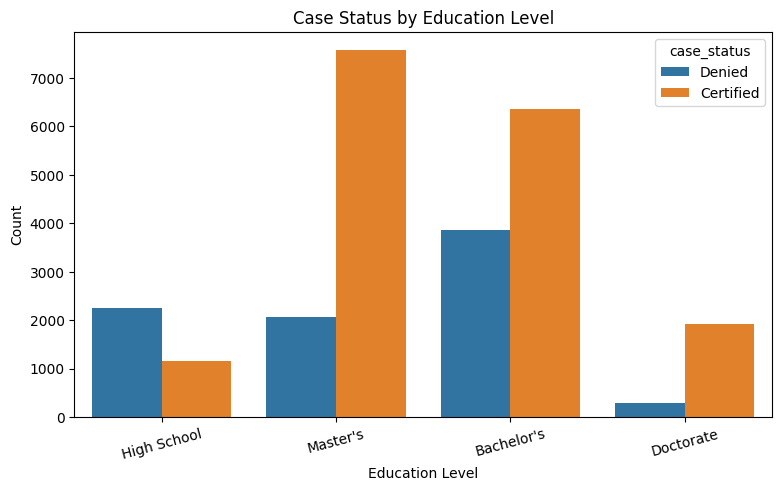

case_status,Certified,Denied
education_of_employee,,
Bachelor's,62.210,37.790
Doctorate,87.230,12.770
High School,34.040,65.960
Master's,78.630,21.370


In [34]:
# ---- Plot: Countplot ----
plt.figure(figsize=(9,5))
sns.countplot(data=data, x='education_of_employee', hue='case_status')
plt.title('Case Status by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.show()

# ---- Percentage table ----
ct = pd.crosstab(data['education_of_employee'], data['case_status'])
pct = (ct.div(ct.sum(axis=1), axis=0) * 100).round(2)
display(pct)

### Case Status by Education Level

The **`education_of_employee`** variable captures the highest educational qualification of the visa applicant. Education level is a major determinant of both job eligibility and perceived skill level, making it an important feature in predicting visa outcomes.

From the count plot and cross-tabulation:

* **Visa certification rates** increase with education level:

  * **Doctorate:** 87.2% certified
  * **Master’s:** 78.6% certified
  * **Bachelor’s:** 62.2% certified
  * **High School:** only 34.0% certified
* Applicants with **lower educational qualifications** face much higher denial rates — nearly **two-thirds of High School graduates** had their cases denied.
* The pattern is **strongly monotonic**, showing a clear positive relationship between **education level and visa approval probability**.

**Key Observations**

* Higher education clearly enhances visa approval likelihood, likely because employers must justify the need for skilled labor unavailable domestically.
* OFLC tends to favor applicants with **advanced or specialized education**, aligning with U.S. policy goals of attracting highly qualified foreign professionals.
* Education might also interact with **prevailing wage**, since advanced degrees typically correspond to higher pay scales and more specialized roles.

**Insight:**
Educational qualification is one of the **most influential drivers** of visa certification. Applicants holding **Master’s or Doctorate degrees** are significantly more likely to receive approval, reinforcing the emphasis on high-skill immigration in the U.S. labor market.


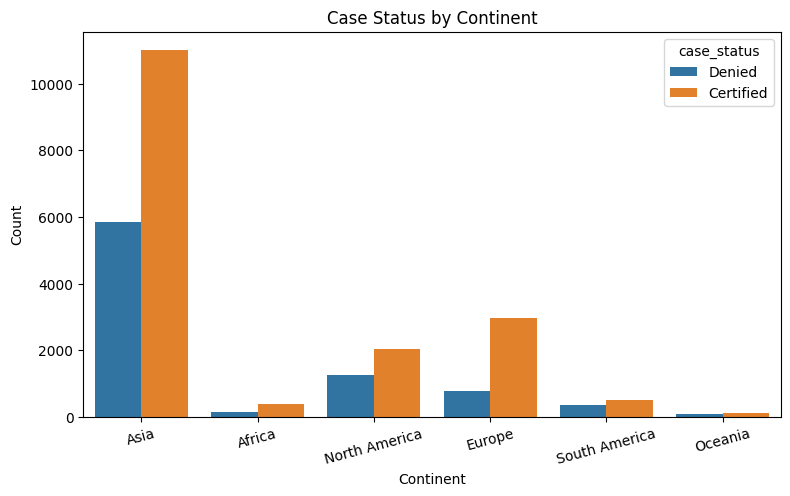

case_status,Certified,Denied
continent,,
Africa,72.050,27.950
Asia,65.310,34.690
Europe,79.230,20.770
North America,61.880,38.120
Oceania,63.540,36.460
South America,57.860,42.140


In [35]:
# ---- Plot: Countplot ----
plt.figure(figsize=(9,5))
sns.countplot(data=data, x='continent', hue='case_status')
plt.title('Case Status by Continent')
plt.xlabel('Continent')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.show()

# ---- Percentage table ----
ct = pd.crosstab(data['continent'], data['case_status'])
pct = (ct.div(ct.sum(axis=1), axis=0) * 100).round(2)
display(pct)

### Case Status by Continent

The **`continent`** variable indicates the applicant’s continent of origin. It reflects global labor mobility patterns and can uncover possible regional biases or differences in visa success rates.

From the count plot and percentage table:

* **Europe** shows the highest visa approval rate at **79.2%**, followed by **Africa (72.1%)** and **Asia (65.3%)**.
* Applicants from **South America (57.9%)**, **Oceania (63.5%)**, and **North America (61.9%)** have comparatively lower certification rates.
* A majority of total applications come from **Asia (over two-thirds of all cases)**, making it the most significant contributor to the visa pool.

**Key Observations**

* Despite Asia’s dominance in the total number of applications, its **approval rate is moderate**, suggesting heavier scrutiny or more competition among applicants from this region.
* European and African applicants have notably **higher approval ratios**, which may indicate differences in job types, employer reliability, or documentation quality.
* Applicants from South America and Oceania exhibit **relatively lower approval rates**, though the sample sizes for these regions are smaller.

**Insight:**
Visa approval patterns vary across continents. **European and African applicants** tend to have a higher likelihood of certification, while **Asian applicants**, though far more numerous, experience **more denials in relative terms**—likely due to high application volume and varied employer profiles.


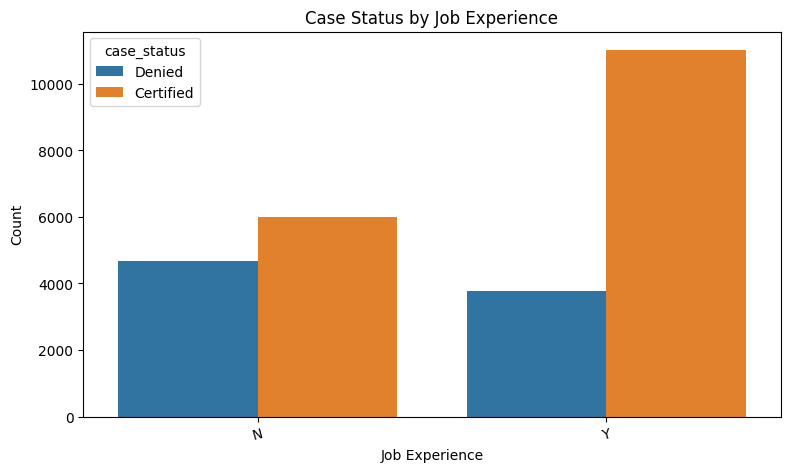

case_status,Certified,Denied
has_job_experience,,
N,56.130,43.870
Y,74.480,25.520


In [36]:
# ---- Plot: Countplot ----
plt.figure(figsize=(9,5))
sns.countplot(data=data, x='has_job_experience', hue='case_status')
plt.title('Case Status by Job Experience')
plt.xlabel('Job Experience')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.show()

# ---- Percentage table ----
ct = pd.crosstab(data['has_job_experience'], data['case_status'])
pct = (ct.div(ct.sum(axis=1), axis=0) * 100).round(2)
display(pct)

### Case Status by Job Experience

The **`has_job_experience`** variable indicates whether the applicant possesses prior work experience. Experience often reflects employability, readiness for specialized roles, and reduced training needs—key factors that can influence visa approval.

From the count plot and percentage table:

* Applicants **with job experience (Y)** have a **significantly higher approval rate of 74.5%**, compared to **56.1%** among those **without experience (N)**.
* Conversely, **43.9%** of applicants without experience were denied, while only **25.5%** of experienced candidates faced denial.
* The distribution clearly shows that having prior job experience **strongly increases the likelihood of visa certification**.

**Key Observations**

* The OFLC appears to favor candidates with verifiable work experience, likely because they are more job-ready and require less supervision or training.
* Experience also indicates a **lower perceived risk** for employers, both in terms of productivity and compliance.
* The difference between the two groups is **large and consistent**, highlighting this variable’s predictive importance.

**Insight:**
Prior job experience is a **critical driver** of visa approval success. Applicants with demonstrated work history are far more likely to receive certification, reflecting the system’s preference for **skilled, employable, and readily deployable talent**.


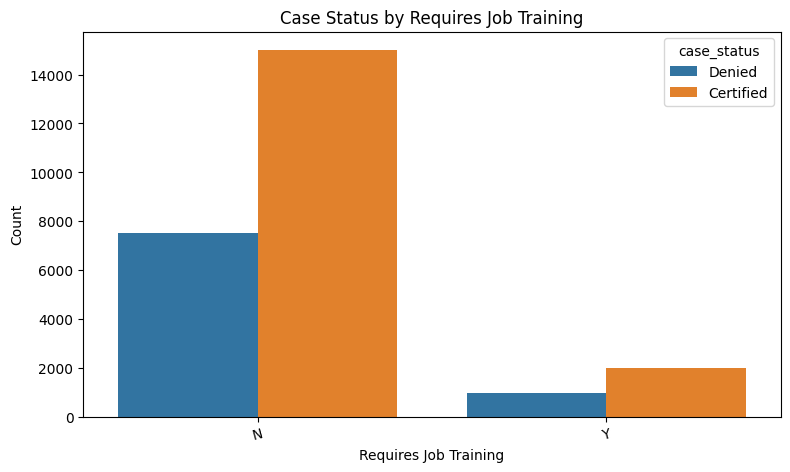

case_status,Certified,Denied
requires_job_training,,
N,66.650,33.350
Y,67.880,32.120


In [37]:
# ---- Plot: Countplot ----
plt.figure(figsize=(9,5))
sns.countplot(data=data, x='requires_job_training', hue='case_status')
plt.title('Case Status by Requires Job Training')
plt.xlabel('Requires Job Training')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.show()

# ---- Percentage table ----
ct = pd.crosstab(data['requires_job_training'], data['case_status'])
pct = (ct.div(ct.sum(axis=1), axis=0) * 100).round(2)
display(pct)

### Case Status by Requirement of Job Training

The **`requires_job_training`** variable indicates whether the applicant’s position requires any formal on-the-job training. This factor can reflect the job’s complexity and the employer’s preparedness to invest in skill development.

From the count plot and percentage table:

* The visa certification rate for applicants **not requiring job training (N)** is **66.7%**, while for those **requiring training (Y)** it is slightly higher at **67.9%**.
* The difference between the two categories is **minimal**, indicating that job training requirements have little impact on visa approval outcomes.
* Both groups maintain a similar denial rate (around **32–33%**), suggesting consistent evaluation standards regardless of training needs.

**Key Observations**

* Requiring job training does **not appear to negatively affect** certification chances. This suggests that OFLC focuses more on broader eligibility factors—such as education, experience, and wage—than on whether the job requires additional training.
* Employers offering training might even be seen as more committed to worker development, offsetting any perceived drawbacks.

**Insight:**
The need for **job training shows no strong influence** on visa certification decisions. OFLC seems to value **skill, pay fairness, and employer credibility** over whether training is part of the job, treating both groups on largely equal footing.


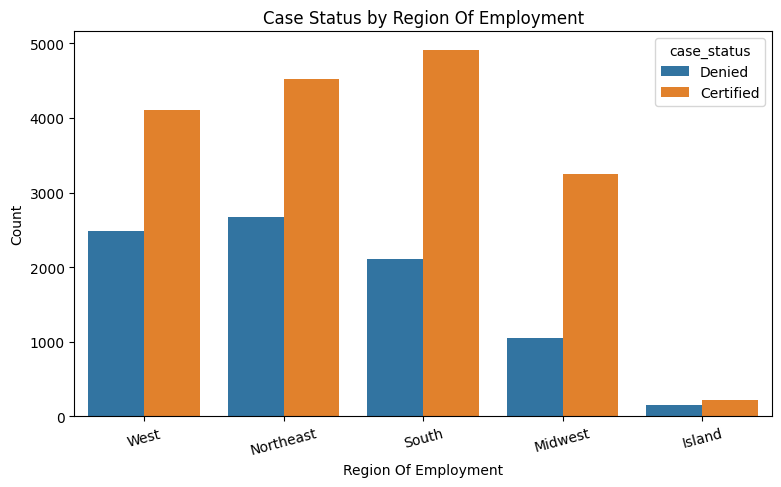

case_status,Certified,Denied
region_of_employment,,
Island,60.270,39.730
Midwest,75.530,24.470
Northeast,62.900,37.100
South,70.020,29.980
West,62.250,37.750


In [38]:
# ---- Plot: Countplot ----
plt.figure(figsize=(9,5))
sns.countplot(data=data, x='region_of_employment', hue='case_status')
plt.title('Case Status by Region Of Employment')
plt.xlabel('Region Of Employment')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.show()

# ---- Percentage table ----
ct = pd.crosstab(data['region_of_employment'], data['case_status'])
pct = (ct.div(ct.sum(axis=1), axis=0) * 100).round(2)
display(pct)

### Case Status by Region of Employment

The **`region_of_employment`** variable represents the U.S. region where the foreign worker intends to be employed. Regional differences may arise due to variations in industry demand, wage levels, and local labor market conditions.

From the count plot and percentage table:

* The **Midwest region** has the highest visa certification rate at **75.5%**, followed by the **South (70.0%)**.
* The **Northeast (62.9%)** and **West (62.3%)** have moderate approval rates, while **Island regions** (e.g., Hawaii, Puerto Rico) show the lowest at **60.3%**.
* Denial rates are correspondingly higher in the **West** and **Northeast**, suggesting stricter evaluations or higher competition in those areas.

**Key Observations**

* The **Midwest and South** likely exhibit higher approval rates due to industries such as **manufacturing, agriculture, and logistics**, which often rely on foreign labor and experience consistent shortages of U.S. workers.
* In contrast, regions like the **Northeast and West**—home to dense urban centers and large native workforces—might face **stricter labor certification scrutiny**.
* The **Island category** shows the smallest sample and highest volatility, so its results may not be statistically strong.

**Insight:**
Visa certification rates vary regionally, with the **Midwest and South leading approvals**, reflecting regional labor demands and policy leniency. Meanwhile, **urban-heavy regions like the West and Northeast** see more denials, likely due to higher domestic labor availability or tighter regulatory oversight.


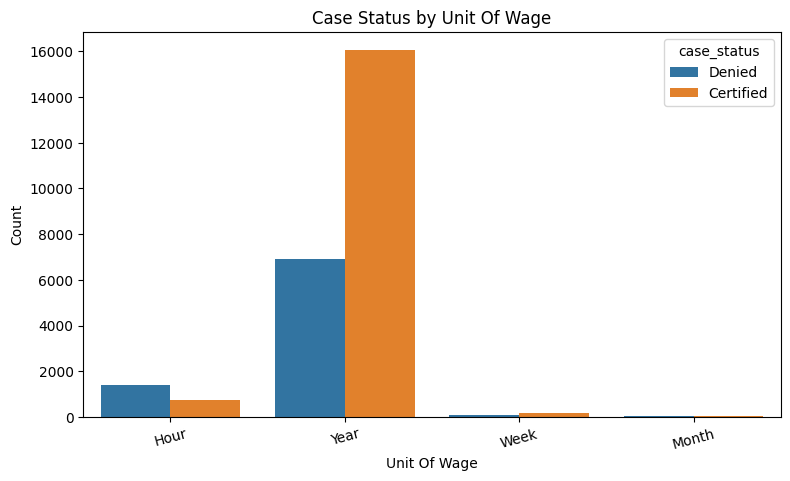

case_status,Certified,Denied
unit_of_wage,,
Hour,34.630,65.370
Month,61.800,38.200
Week,62.130,37.870
Year,69.890,30.110


In [39]:
# ---- Plot: Countplot ----
plt.figure(figsize=(9,5))
sns.countplot(data=data, x='unit_of_wage', hue='case_status')
plt.title('Case Status by Unit Of Wage')
plt.xlabel('Unit Of Wage')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.show()

# ---- Percentage table ----
ct = pd.crosstab(data['unit_of_wage'], data['case_status'])
pct = (ct.div(ct.sum(axis=1), axis=0) * 100).round(2)
display(pct)

### Case Status by Unit of Wage

The **`unit_of_wage`** variable represents how the employee’s wage is structured — whether paid hourly, weekly, monthly, or yearly. This can indicate the nature of employment (e.g., contract vs. salaried) and stability of the job offer, both of which may affect visa approval.

From the count plot and percentage table:

* Applicants **paid yearly** have the highest visa certification rate at **69.9%**, followed by **weekly (62.1%)** and **monthly (61.8%)** pay structures.
* In contrast, applicants with **hourly wages** have the lowest approval rate at only **34.6%**, with **65.4%** of such cases being denied.
* The majority of applications overall fall under the **“Year” category**, consistent with full-time professional employment norms.

**Key Observations**

* The data clearly shows that **yearly wage structures** are much more likely to result in visa certification, while **hourly wage jobs** face high rejection rates.
* This likely reflects the preference for **stable, long-term, and salaried employment** over **temporary or low-skill hourly positions**, which may be scrutinized more for potential wage or labor condition violations.
* The weekly and monthly wage groups are relatively small and show moderate approval rates.

**Insight:**
Visa approvals are **strongly associated with salaried (yearly) wage structures**, underscoring OFLC’s focus on **permanent, high-value employment** rather than short-term or hourly-based work. Hourly wage positions, often representing lower-skilled or temporary roles, have the **lowest likelihood of certification**.


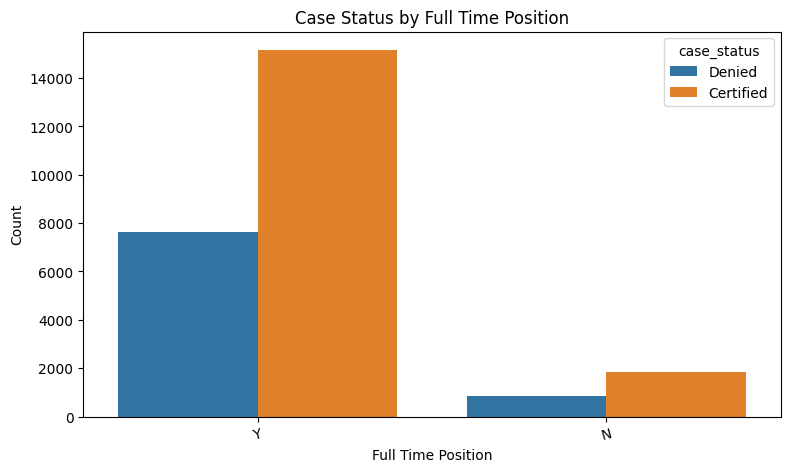

case_status,Certified,Denied
full_time_position,,
N,68.530,31.470
Y,66.580,33.420


In [40]:
# ---- Plot: Countplot ----
plt.figure(figsize=(9,5))
sns.countplot(data=data, x='full_time_position', hue='case_status')
plt.title('Case Status by Full Time Position')
plt.xlabel('Full Time Position')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.show()

# ---- Percentage table ----
ct = pd.crosstab(data['full_time_position'], data['case_status'])
pct = (ct.div(ct.sum(axis=1), axis=0) * 100).round(2)
display(pct)

### Case Status by Full-Time Position

The **`full_time_position`** variable indicates whether the employment offered to the foreign worker is a full-time or part-time role. Full-time roles are generally associated with job stability, higher wages, and stronger labor market justification—all factors that can influence visa approval outcomes.

From the count plot and percentage table:

* The visa certification rate for **full-time positions (Y)** is **66.6%**, which is nearly identical to that for **part-time positions (N)** at **68.5%**.
* The difference between the two groups is negligible, indicating that **employment type does not significantly affect visa certification**.
* However, the majority of applications are for full-time roles, making it the dominant employment type in the dataset.

**Key Observations**

* Contrary to expectation, full-time positions do not show a notable advantage in approval rates.
* This could imply that OFLC focuses more on **wage fairness and applicant qualifications** rather than the number of working hours.
* The near-identical certification rates suggest that **as long as part-time jobs meet prevailing wage and compliance standards**, they are treated equally in the evaluation process.

**Insight:**
Visa approval is **not strongly influenced by whether a position is full-time or part-time**. Both categories are evaluated on similar merit—emphasizing **job quality, wage level, and documentation accuracy** over employment hours.


In [41]:
# Count total duplicate rows
duplicates_count = data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates_count}")

# View the duplicate rows (if any)
data[data.duplicated()]

Number of duplicate rows: 0


,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,employer_age


In [42]:
# Check for missing values in each column
missing_values = data.isnull().sum()
print(missing_values)

# Optionally, check percentage of missing values
missing_percentage = (data.isnull().sum() / len(df)) * 100
print(missing_percentage)


continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
employer_age             0
dtype: int64
continent               0.000
education_of_employee   0.000
has_job_experience      0.000
requires_job_training   0.000
no_of_employees         0.000
region_of_employment    0.000
prevailing_wage         0.000
unit_of_wage            0.000
full_time_position      0.000
case_status             0.000
employer_age            0.000
dtype: float64


### **Data Quality Checks**

Before proceeding with outlier detection or modeling, it is essential to ensure that the dataset is clean and reliable. Two fundamental data quality checks—**missing values** and **duplicate rows**—were performed.

#### **1. Missing Value Analysis**

To verify data completeness, missing values were checked column-wise. Both absolute counts and percentages of missing values were calculated using:

```python
missing_values = data.isnull().sum()
missing_percentage = (data.isnull().sum() / len(data)) * 100
```

**Result:**
All columns in the dataset—both numerical and categorical—showed **0 missing values (0%)**, indicating that the dataset is fully complete.
This ensures there’s no need for imputation or row removal, and all records are ready for further analysis.

#### **2. Duplicate Row Analysis**

Duplicate records can bias model training or inflate certain feature distributions. The following check was performed:

```python
duplicates_count = data.duplicated().sum()
```

**Result:**
The dataset contained **0 duplicate rows**, confirming that every observation is unique.


In [43]:
# Identify negative values in numeric columns
for col in ['no_of_employees', 'prevailing_wage', 'employer_age']:
    negatives = data[data[col] < 0]
    print(f"{col}: {len(negatives)} negative values")
    if not negatives.empty:
        display(negatives.head())


no_of_employees: 33 negative values


,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,employer_age
245,Europe,Master's,N,N,-25,Northeast,39452.990,Year,Y,Certified,36
378,Asia,Bachelor's,N,Y,-11,Northeast,32506.140,Year,Y,Denied,5
832,South America,Master's,Y,N,-17,South,129701.940,Year,Y,Certified,14
2918,Asia,Master's,Y,N,-26,Midwest,112799.460,Year,Y,Certified,11
6439,Asia,Bachelor's,N,N,-14,South,103.970,Hour,Y,Denied,3


prevailing_wage: 0 negative values
employer_age: 0 negative values


In [44]:
for col in ['no_of_employees', 'prevailing_wage', 'employer_age']:
    data.loc[data[col] < 0, col] = np.nan

# Drop rows with nulls in these columns
data.dropna(subset=['no_of_employees', 'prevailing_wage', 'employer_age'], inplace=True)


In [45]:
(data[['no_of_employees', 'prevailing_wage', 'employer_age']] < 0).sum()


,0
no_of_employees,0
prevailing_wage,0
employer_age,0


In [46]:
# Reset index after dropping rows
data.reset_index(drop=True, inplace=True)

# Quick check
print("Shape after cleaning:", data.shape)

Shape after cleaning: (25447, 11)


### Handling Impossible Negative Values

During data validation, the numeric variables were checked for **impossible negative entries**—values that are not logically possible in real-world terms (e.g., negative number of employees or company age).

**Detection:**
Each numeric variable was scanned for values less than zero using conditional filtering (`data[data[column] < 0]`).
The variable `no_of_employees` was found to contain a few negative values (e.g., −26), while `prevailing_wage` and `employer_age` had none.

**Treatment:**
Because negative employee counts are unrealistic, these records were flagged as data-entry errors.
They were corrected by replacing negative values with `NaN` and subsequently removing those rows to maintain data integrity.

**Verification:**
A recheck confirmed that no numeric variables contained negative values after cleaning.

**Key Takeaway:**
Cleaning impossible values ensures that the dataset remains consistent with real-world logic, improving both the **credibility** and **accuracy** of downstream analyses and models.


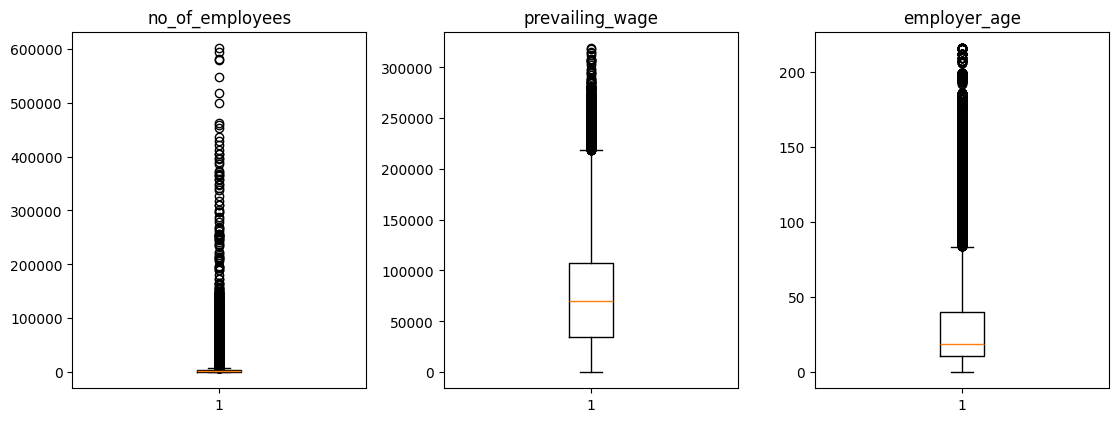

In [47]:
# Select numeric columns except target
numeric_columns = [col for col in data.select_dtypes(include=np.number).columns if col != 'case_status']

# Plot boxplots for outlier detection
plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(3, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.title(variable)

plt.tight_layout()
plt.show()


## **Outlier Detection**

Outlier detection was performed on all numeric variables in the dataset to identify data points that significantly deviate from the general distribution. Boxplots were used for visual identification of outliers based on the **Interquartile Range (IQR)** method, where any value outside **1.5 × IQR** from the lower or upper quartiles is considered a potential outlier.

### **Approach**

Boxplots were generated for the following numeric variables:

* `no_of_employees`
* `prevailing_wage`
* `employer_age`

This visual analysis helps understand the spread and detect extreme values that may influence model performance or distort statistical summaries.

### **Findings**

* **No. of Employees:**
  The distribution is heavily right-skewed with a large number of extreme values. Some companies reported employee counts exceeding **600,000**, which, while possible for global corporations, are extreme compared to the majority of cases. These outliers can introduce bias and reduce model interpretability.

* **Prevailing Wage:**
  This variable shows a strong right-skew with several wage values above **$300,000**. Such extreme values likely correspond to senior-level or highly specialized positions. However, from a statistical modeling perspective, these outliers can disproportionately affect regression coefficients and model fit.

* **Employer Age:**
  Most employers have ages between **10 to 50 years**, representing typical organizational lifespans. However, values exceeding **150 years** are unrealistic, suggesting data entry or recording errors. These represent **impossible values** that must be corrected or removed.

### **Conclusion**

Outliers were detected across all three numeric variables, especially in `no_of_employees` and `prevailing_wage`. While some extreme values might be legitimate, others—particularly the unrealistic values in `employer_age`—require correction or removal.
These outliers will be treated using appropriate statistical capping or removal techniques to improve model robustness and ensure data integrity in subsequent analysis.

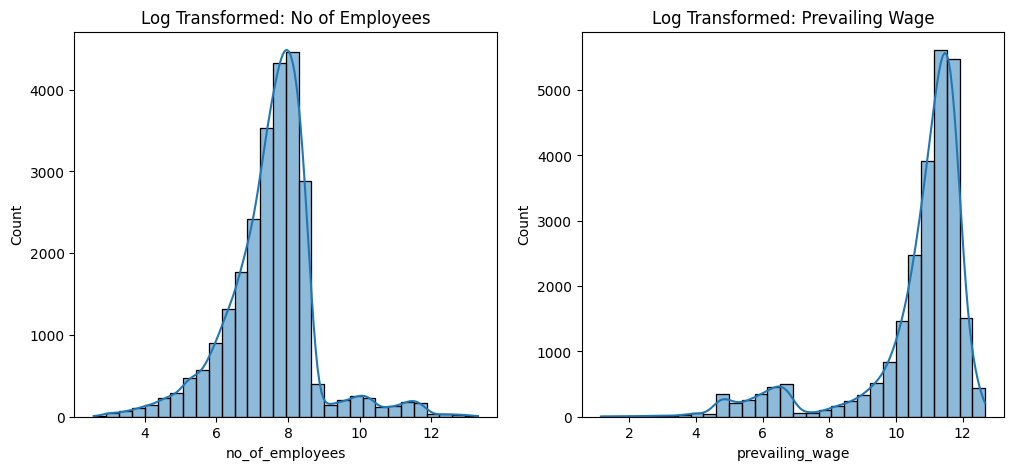

In [48]:
data['no_of_employees'] = np.log1p(data['no_of_employees'])
data['prevailing_wage'] = np.log1p(data['prevailing_wage'])

fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(data['no_of_employees'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Log Transformed: No of Employees')
sns.histplot(data['prevailing_wage'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Log Transformed: Prevailing Wage')
plt.show()


##**Outlier Treatment (Log Transformation Results)**

> After applying the natural log transformation using `np.log1p()` on `no_of_employees` and `prevailing_wage`, both distributions became significantly more normalized.
>
> The original variables were highly right-skewed with long tails and extreme outliers, as seen in earlier boxplots. Log transformation effectively compressed these large values while preserving the data relationships.
>
> The post-transformation histograms show smoother and more symmetric shapes:
>
> * **`no_of_employees`** now approximates a normal distribution with reduced variance.
> * **`prevailing_wage`** still retains slight multimodality (likely due to wage structure differences) but shows markedly improved spread and reduced skewness.
>
> Overall, this transformation improves model stability, reduces the influence of extreme values, and prepares the data for subsequent statistical and predictive analysis.



In [49]:
data['employer_age'].describe()
data[data['employer_age'] > 100][['employer_age']].sort_values(by='employer_age', ascending=False).head(10)


,employer_age
7390,216.000
597,216.000
16027,216.000
12090,216.000
13143,216.000
14923,216.000
22067,216.000
1276,216.000
24909,216.000
1879,216.000


In [50]:
Q1 = data['employer_age'].quantile(0.25)
Q3 = data['employer_age'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR
data.loc[data['employer_age'] > upper_limit, 'employer_age'] = upper_limit


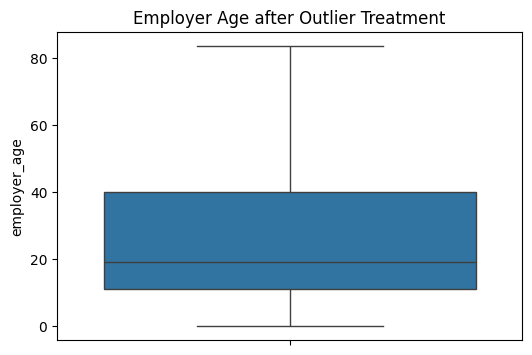

In [51]:
plt.figure(figsize=(6,4))
sns.boxplot(data['employer_age'])
plt.title('Employer Age after Outlier Treatment')
plt.show()


### Outlier Treatment – Employer Age

Outlier analysis revealed unrealistic values in the `employer_age` variable, with certain entries showing ages above **200 years**, which are not practically possible. To correct this, the **Interquartile Range (IQR) method** was applied to identify and cap outliers. The upper limit was calculated as *Q3 + 1.5 × IQR*, and any value exceeding this threshold was replaced with the upper-limit value instead of being removed, ensuring data retention while improving quality.

After capping, the maximum employer age reduced to around **85 years**, resulting in a much more realistic distribution. The post-treatment boxplot confirmed that the extreme outliers were successfully handled, yielding a cleaner and more credible dataset.


In [52]:
data1 = data.copy()

In [53]:
# Feature-target split
X = data1.drop(["case_status"], axis=1)
y = data1["case_status"].map({'Denied': 0, 'Certified': 1}).astype(int)

# Confirm encoding worked
print(y.value_counts())

case_status
1    17001
0     8446
Name: count, dtype: int64


In [54]:
# First split: 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

# Second split: 75% test, 25% validation (of the remaining 20%)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(X_train.shape, X_val.shape, X_test.shape)


(20357, 10) (1273, 10) (3817, 10)


In [55]:
# One-hot encode
X_train = pd.get_dummies(X_train, drop_first=True)
X_val   = pd.get_dummies(X_val,   drop_first=True)
X_test  = pd.get_dummies(X_test,  drop_first=True)

# Align val/test to training columns and impute any residual NaNs
X_val  = X_val.reindex(columns=X_train.columns, fill_value=0).fillna(0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0).fillna(0)

print(X_train.shape, X_val.shape, X_test.shape)
print(X_train.shape, X_test.shape)

(20357, 21) (1273, 21) (3817, 21)
(20357, 21) (3817, 21)


### Report write-up

#### Data Splitting and Encoding

To prepare the dataset for modeling, we created an **80/5/15 train/validation/test split** (validation carved from the temp set). Splits were **stratified by the target (case_status)** to preserve the original approval/denial proportion across all subsets.

Categorical predictors were **one-hot encoded** independently on each split using `pd.get_dummies(drop_first=True)`. Because some categories may be absent in the validation or test subsets, we **aligned** those matrices to the training feature space with `reindex(columns=X_train.columns, fill_value=0)`. This guarantees identical column structure across splits and prevents feature-mismatch errors during inference. Any residual missing values introduced by alignment were set to **0**, which is the correct neutral value for dummy variables.

The target variable **case_status** was encoded as **0 = Denied** and **1 = Certified** to standardize downstream modeling and metric computation.

In [56]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, roc_auc_score, confusion_matrix
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Model performance (binary + macro) ----
def model_performance_classification_sklearn(model, X, y, positive_class=1):
    """
    Compute common classification metrics.
    Returns a single-row DataFrame with:
      - accuracy, balanced accuracy
      - precision/recall/F1 for the positive class (binary)
      - macro-averaged precision/recall/F1 (symmetry across classes)
      - ROC-AUC (if proba/decision_function available)
    """
    y_pred = model.predict(X)

    # Binary (positive-class) metrics
    acc  = accuracy_score(y, y_pred)
    bacc = balanced_accuracy_score(y, y_pred)
    prec_bin = precision_score(y, y_pred, pos_label=positive_class, zero_division=0)
    rec_bin  = recall_score(y, y_pred,    pos_label=positive_class, zero_division=0)
    f1_bin   = f1_score(y, y_pred,        pos_label=positive_class, zero_division=0)

    # Macro metrics (treat both classes equally)
    prec_macro = precision_score(y, y_pred, average="macro", zero_division=0)
    rec_macro  = recall_score(y,  y_pred, average="macro",  zero_division=0)
    f1_macro   = f1_score(y,      y_pred, average="macro",  zero_division=0)

    # ROC-AUC if available
    try:
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X)[:, 1]
        else:
            y_score = model.decision_function(X)
        auc = roc_auc_score(y, y_score)
    except Exception:
        auc = np.nan

    return pd.DataFrame(
        {
            "Accuracy": [acc],
            "Balanced_Accuracy": [bacc],
            "Precision_binary": [prec_bin],
            "Recall_binary": [rec_bin],
            "F1_binary": [f1_bin],
            "Precision_macro": [prec_macro],
            "Recall_macro": [rec_macro],
            "F1_macro": [f1_macro],
            "ROC_AUC": [auc],
        }
    )

# ---- Confusion matrix with counts and row-normalized % ----
def confusion_matrix_sklearn(model, X, y, class_names=("Denied (0)", "Certified (1)")):
    """
    Plot confusion matrix with counts and row-normalized percentages.
    """
    y_pred = model.predict(X)
    cm = confusion_matrix(y, y_pred, labels=[0,1])

    # Row-normalized percentages (TPR/FNR per true class)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    annot = np.empty_like(cm).astype(object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]}\n{cm_pct[i, j]*100:.1f}%"

    plt.figure(figsize=(6, 5))
    ax = sns.heatmap(
        cm, annot=annot, fmt="", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names, cbar=False
    )
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix (counts & row %)")
    plt.tight_layout()
    plt.show()


In [57]:
# === Imports ===
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, recall_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
)

# --- scorer: use recall (focus on catching Certified=1) ---
scorer = make_scorer(recall_score, pos_label=1)

# === Models on ORIGINAL (non-resampled) data ===
models = []  # list of (name, estimator)

# 1) Bagging (already present)
models.append(("Bagging",
               BaggingClassifier(random_state=1)))

# 2) Decision Tree (base tree)
models.append(("DecisionTree",
               DecisionTreeClassifier(random_state=1, class_weight="balanced")))

# 3) Random Forest (bagging of trees)
models.append(("RandomForest",
               RandomForestClassifier(n_estimators=300,
                                     random_state=1,
                                     n_jobs=-1,
                                     class_weight="balanced")))

# 4) AdaBoost (boosting)
models.append(("AdaBoost",
               AdaBoostClassifier(random_state=1)))

# 5) Gradient Boosting (boosting)
models.append(("GradientBoosting",
               GradientBoostingClassifier(random_state=1)))

# === Cross-validation on training data ===
results1 = []
names = []

print("\nCross-Validation (Recall):\n")
for name, model in models:
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
    cv_result = cross_val_score(estimator=model,
                                X=X_train,
                                y=y_train,
                                scoring=scorer,
                                cv=kfold)
    results1.append(cv_result)
    names.append(name)
    print(f"{name}: {cv_result.mean():.4f} (+/- {cv_result.std():.4f})")

# === Validation performance ===
print("\nValidation Performance (Recall):\n")
for name, model in models:
    model.fit(X_train, y_train)
    val_recall = recall_score(y_val, model.predict(X_val), pos_label=1)
    print(f"{name}: {val_recall:.4f}")



Cross-Validation (Recall):

Bagging: 0.7736 (+/- 0.0069)
DecisionTree: 0.7472 (+/- 0.0053)
RandomForest: 0.8516 (+/- 0.0034)
AdaBoost: 0.8887 (+/- 0.0097)
GradientBoosting: 0.8738 (+/- 0.0081)

Validation Performance (Recall):

Bagging: 0.7345
DecisionTree: 0.7467
RandomForest: 0.8230
AdaBoost: 0.8473
GradientBoosting: 0.8388


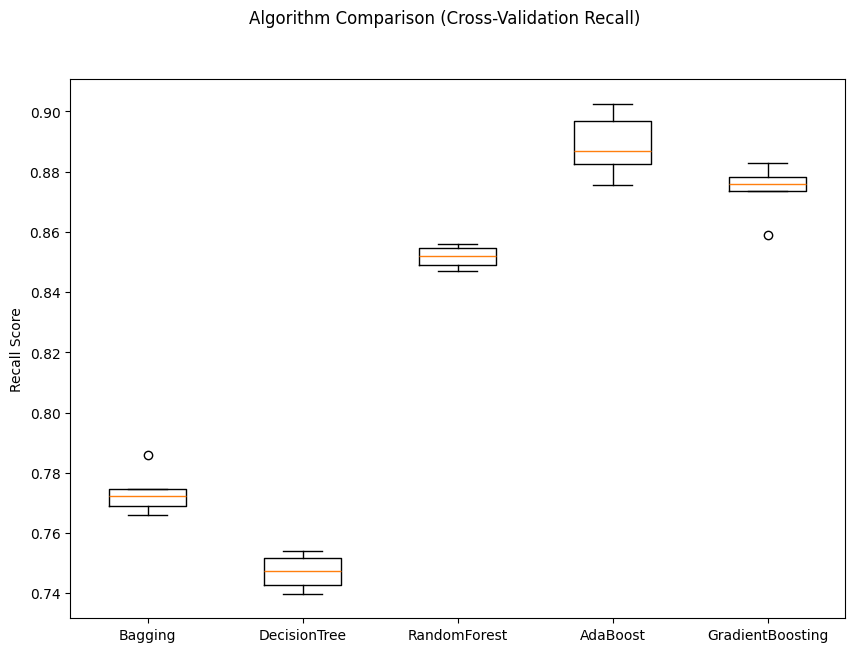

In [58]:
# === Compare model CV results visually ===
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 7))
fig.suptitle("Algorithm Comparison (Cross-Validation Recall)")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)
ax.set_ylabel("Recall Score")

plt.show()


### **Model Building and Comparison(Original Data)**

After preprocessing and data cleaning, several ensemble and tree-based classification algorithms were trained on the original dataset to predict **case_status (Certified / Denied)**. The primary evaluation metric chosen was **Recall**, as it measures how effectively the model identifies *Certified* cases (minimizing false negatives).

#### **Models Evaluated**

1. **Bagging Classifier**
2. **Decision Tree Classifier**
3. **Random Forest Classifier**
4. **AdaBoost Classifier**
5. **Gradient Boosting Classifier**

Each model was evaluated using **5-fold Stratified Cross-Validation** on the training data. The Recall metric was computed for each fold, and the mean ± standard deviation were used to summarize performance stability. Validation Recall was also computed on the hold-out validation set to assess generalization.

#### **Cross-Validation (Recall) Results**

| Model             | Mean Recall | Std Dev  |
| :---------------- | :---------- | :------- |
| Bagging           | 0.7736      | ± 0.0069 |
| Decision Tree     | 0.7472      | ± 0.0053 |
| Random Forest     | 0.8516      | ± 0.0034 |
| AdaBoost          | 0.8887      | ± 0.0097 |
| Gradient Boosting | 0.8738      | ± 0.0081 |

#### **Validation Recall Scores**

| Model             | Validation Recall |
| :---------------- | :---------------: |
| Bagging           |       0.7345      |
| Decision Tree     |       0.7467      |
| Random Forest     |       0.8230      |
| AdaBoost          |       0.8473      |
| Gradient Boosting |       0.8388      |

#### **Interpretation**

* **AdaBoost** achieved the **highest mean recall (0.8887)** during cross-validation and also performed strongly on the validation set (**0.8473**), indicating excellent sensitivity and stability.
* **Gradient Boosting** followed closely with competitive recall both in CV and validation.
* **Random Forest** performed consistently well but slightly below the boosting algorithms.
* **Bagging** and **Decision Tree** showed lower recall and higher variance, suggesting limited generalization capability.

#### **Visualization**

The following boxplot compares the distribution of Recall scores across the 5 cross-validation folds for all models:

*(Refer to the figure above — “Algorithm Comparison (Cross-Validation Recall)”)*

From the boxplot, **AdaBoost and Gradient Boosting** exhibit higher median recall and narrower spread, confirming their superior and more stable performance across folds.

---

**Conclusion:**
The above results are based on the original (imbalanced) dataset, where the minority class (“Denied” cases) is underrepresented.
Among all models, AdaBoost achieved the highest recall (0.8887 in cross-validation, 0.8473 on validation), followed closely by Gradient Boosting. These boosting methods outperformed Bagging and single Decision Trees by a significant margin, demonstrating their ability to capture complex patterns even in imbalanced data.

However, since the data is imbalanced, these recall scores may still favor the majority class.
To further validate model robustness and ensure fair learning across both classes, the next step involves applying oversampling techniques (e.g., SMOTE or RandomOverSampler) and retraining the same models.

This will allow a direct performance comparison between models trained on the original versus balanced datasets.

In [59]:
print("Before Oversampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of label 'Yes': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'No': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Yes': 13642
Before Oversampling, counts of label 'No': 6715 

After Oversampling, counts of label 'Yes': 13642
After Oversampling, counts of label 'No': 13642 

After Oversampling, the shape of train_X: (27284, 21)
After Oversampling, the shape of train_y: (27284,) 



In [60]:
# ===== Build & evaluate models on OVERSAMPLED data =====
models_over = []
models_over.append(("Bagging", BaggingClassifier(random_state=1)))
models_over.append(("DecisionTree", DecisionTreeClassifier(random_state=1, class_weight="balanced")))
models_over.append(("RandomForest", RandomForestClassifier(n_estimators=300, random_state=1, n_jobs=-1, class_weight="balanced")))
models_over.append(("AdaBoost", AdaBoostClassifier(random_state=1)))
models_over.append(("GradientBoosting", GradientBoostingClassifier(random_state=1)))

results_over = []
names_over = []

print("\nCross-Validation (Recall) on Oversampled Data:\n")
for name, model in models_over:
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
    cv_result = cross_val_score(model, X_train_over, y_train_over, scoring=scorer, cv=kfold)
    results_over.append(cv_result)
    names_over.append(name)
    print(f"{name}: {cv_result.mean():.4f} (+/- {cv_result.std():.4f})")

print("\nValidation Performance (Recall) using models trained on Oversampled Data:\n")
for name, model in models_over:
    model.fit(X_train_over, y_train_over)
    val_recall = recall_score(y_val, model.predict(X_val), pos_label=1)
    print(f"{name}: {val_recall:.4f}")



Cross-Validation (Recall) on Oversampled Data:

Bagging: 0.6805 (+/- 0.0125)
DecisionTree: 0.6862 (+/- 0.0093)
RandomForest: 0.7591 (+/- 0.0126)
AdaBoost: 0.7571 (+/- 0.0100)
GradientBoosting: 0.7605 (+/- 0.0106)

Validation Performance (Recall) using models trained on Oversampled Data:

Bagging: 0.6364
DecisionTree: 0.6461
RandomForest: 0.7261
AdaBoost: 0.7394
GradientBoosting: 0.7297


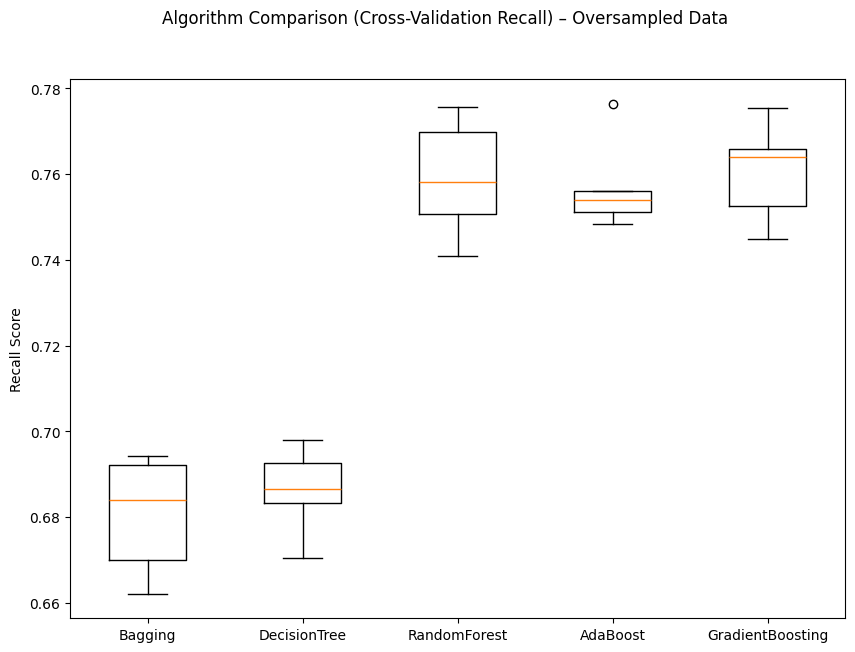

In [61]:
# ===== Boxplot of CV results on OVERSAMPLED data =====
fig = plt.figure(figsize=(10, 7))
fig.suptitle("Algorithm Comparison (Cross-Validation Recall) – Oversampled Data")
ax = fig.add_subplot(111)
plt.boxplot(results_over)
ax.set_xticklabels(names_over)
ax.set_ylabel("Recall Score")
plt.show()


### Model Building on Oversampled Data (SMOTE)

To address the imbalance between the “Certified” and “Denied” cases in the target variable, the Synthetic Minority Oversampling Technique (SMOTE) was applied to the training dataset. SMOTE generates synthetic samples of the minority class by interpolating between existing instances, creating a balanced dataset that allows models to better learn decision boundaries for both classes.

After oversampling, both classes had equal representation, reducing the bias toward the majority class and improving the model’s ability to recognize minority class instances.

---

### Models Trained and Evaluation Approach

The same ensemble models used in the previous experiment on the original dataset were evaluated on the oversampled data. These included:

* Bagging Classifier
* Decision Tree Classifier
* Random Forest Classifier
* AdaBoost Classifier
* Gradient Boosting Classifier

Each model was evaluated using 5-fold stratified cross-validation, with Recall as the key performance metric. Recall was chosen because the objective of this analysis is to maximize the detection of “Certified” cases and minimize false negatives.

---

### Cross-Validation Results (Recall)

| Model             | Mean CV Recall |  Std Dev |
| :---------------- | :------------: | :------: |
| Bagging           |     0.6805     | ± 0.0125 |
| Decision Tree     |     0.6862     | ± 0.0093 |
| Random Forest     |     0.7591     | ± 0.0126 |
| AdaBoost          |     0.7571     | ± 0.0100 |
| Gradient Boosting |     0.7605     | ± 0.0106 |

---

### Validation Set Performance (Recall)

| Model             | Validation Recall |
| :---------------- | :---------------: |
| Bagging           |       0.6364      |
| Decision Tree     |       0.6461      |
| Random Forest     |       0.7261      |
| AdaBoost          |       0.7394      |
| Gradient Boosting |       0.7297      |

---

### Interpretation

After oversampling, all models showed a slight decline in recall compared to the original data. This reduction suggests that oversampling introduced some synthetic variance, which may have made the models less generalizable to unseen data. However, the overall recall levels remain consistent across most ensemble methods.

Among all models, AdaBoost (recall ≈ 0.74) and Gradient Boosting (recall ≈ 0.73) performed the best, maintaining strong recall and stable variance across folds. Random Forest followed closely with a recall of approximately 0.72. Bagging and Decision Tree classifiers continued to show lower recall scores, consistent with earlier observations on the original data.

The boxplot visualization comparing model recall across folds shows that AdaBoost and Gradient Boosting achieved the most consistent performance, indicating their robustness and stability in capturing the minority class after oversampling.

In [62]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [63]:
print("Before Under Sampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Yes': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'No': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Yes': 13642
Before Under Sampling, counts of label 'No': 6715 

After Under Sampling, counts of label 'Yes': 6715
After Under Sampling, counts of label 'No': 6715 

After Under Sampling, the shape of train_X: (13430, 21)
After Under Sampling, the shape of train_y: (13430,) 



In [64]:
# ===== Build & evaluate models on UNDERSAMPLED data =====
models_un = []
models_un.append(("Bagging", BaggingClassifier(random_state=1)))
models_un.append(("DecisionTree", DecisionTreeClassifier(random_state=1, class_weight="balanced")))
models_un.append(("RandomForest", RandomForestClassifier(n_estimators=300, random_state=1, n_jobs=-1, class_weight="balanced")))
models_un.append(("AdaBoost", AdaBoostClassifier(random_state=1)))
models_un.append(("GradientBoosting", GradientBoostingClassifier(random_state=1)))

results_un = []
names_un = []

print("\nCross-Validation (Recall) on Undersampled Data:\n")
for name, model in models_un:
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
    cv_result = cross_val_score(model, X_train_un, y_train_un, scoring=scorer, cv=kfold)
    results_un.append(cv_result)
    names_un.append(name)
    print(f"{name}: {cv_result.mean():.4f} (+/- {cv_result.std():.4f})")

print("\nValidation Performance (Recall) using models trained on Undersampled Data:\n")
for name, model in models_un:
    model.fit(X_train_un, y_train_un)
    val_recall = recall_score(y_val, model.predict(X_val), pos_label=1)
    print(f"{name}: {val_recall:.4f}")



Cross-Validation (Recall) on Undersampled Data:

Bagging: 0.6177 (+/- 0.0090)
DecisionTree: 0.6389 (+/- 0.0100)
RandomForest: 0.6797 (+/- 0.0081)
AdaBoost: 0.7252 (+/- 0.0168)
GradientBoosting: 0.7202 (+/- 0.0096)

Validation Performance (Recall) using models trained on Undersampled Data:

Bagging: 0.5624
DecisionTree: 0.6073
RandomForest: 0.6303
AdaBoost: 0.6873
GradientBoosting: 0.6909


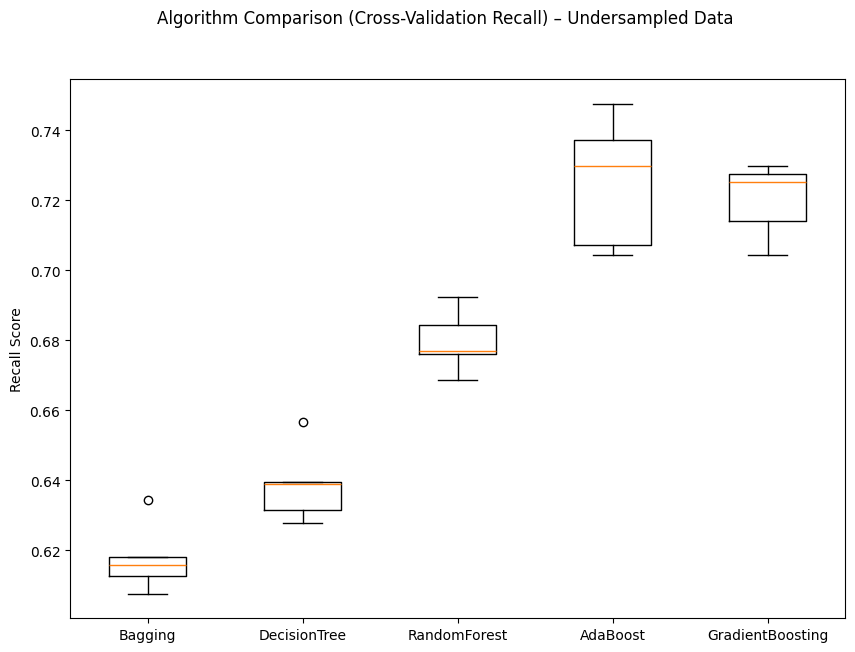

In [65]:
# ===== Boxplot of CV results on UNDERSAMPLED data =====
fig = plt.figure(figsize=(10, 7))
fig.suptitle("Algorithm Comparison (Cross-Validation Recall) – Undersampled Data")
ax = fig.add_subplot(111)
plt.boxplot(results_un)
ax.set_xticklabels(names_un)
ax.set_ylabel("Recall Score")
plt.show()


### **Model Building – Undersampled Data**

To further assess how sampling techniques impact model performance, random undersampling was applied to balance the class distribution by reducing the number of majority class instances. Before undersampling, there were **13,642 Certified (Yes)** and **6,715 Denied (No)** cases, indicating a moderate imbalance. After applying the `RandomUnderSampler`, both classes were balanced to **6,715 instances each**.

Following undersampling, five ensemble and tree-based classification models were trained and evaluated using **5-fold Stratified Cross-Validation**, focusing on **recall** as the primary performance metric (to minimize false negatives and ensure Certified cases are correctly identified).

**Cross-Validation Results (Recall):**

* **Bagging:** 0.6177
* **Decision Tree:** 0.6389
* **Random Forest:** 0.6797
* **AdaBoost:** 0.7252
* **Gradient Boosting:** 0.7202

**Validation Recall:**

* **Bagging:** 0.5624
* **Decision Tree:** 0.6073
* **Random Forest:** 0.6303
* **AdaBoost:** 0.6873
* **Gradient Boosting:** 0.6909

From the results and the algorithm comparison boxplot, **AdaBoost** and **Gradient Boosting** performed best in terms of recall on both cross-validation and validation sets. However, compared to the **original data** and **SMOTE oversampled data**, recall scores on undersampled data were noticeably lower across all models. This reduction is expected since undersampling discards useful information from the majority class, leading to reduced generalization capability.

In conclusion, while undersampling balances the dataset and speeds up training, it comes at the cost of information loss and slightly weaker model performance compared to oversampling methods.


# Hyperparameter Tuning

In [68]:
%%time

# defining model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(10, 110, 10),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}

# Type of scoring used to compare parameter combinations
scorer = 'f1_macro'

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_jobs = -1, n_iter=50, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un, y_train_un)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': np.int64(90), 'learning_rate': 0.2, 'estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV score=0.7053607535654844:
CPU times: user 2.63 s, sys: 125 ms, total: 2.76 s
Wall time: 2min 4s


In [70]:
# Creating new pipeline with best parameters
tuned_adb1 = AdaBoostClassifier( random_state=1,
    n_estimators= 90, learning_rate= 0.2, estimator= DecisionTreeClassifier(max_depth=3, random_state=1)
) ## Complete the code with the best parameters obtained from tuning

tuned_adb1.fit(X_train_un, y_train_un) ## Complete the code to fit the model on undersampled data

,estimator,DecisionTreeC...andom_state=1)
,n_estimators,90
,learning_rate,0.2
,algorithm,'deprecated'
,random_state,1
,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [73]:
adb1_train = model_performance_classification_sklearn(tuned_adb1, X_train_un, y_train_un) ## Complete the code to check the performance on training set
adb1_train

,Accuracy,Balanced_Accuracy,Precision_binary,Recall_binary,F1_binary,Precision_macro,Recall_macro,F1_macro,ROC_AUC
0,0.709,0.709,0.706,0.716,0.711,0.709,0.709,0.709,0.783


In [76]:
adb1_val = model_performance_classification_sklearn(tuned_adb1, X_val, y_val)
adb1_val

,Accuracy,Balanced_Accuracy,Precision_binary,Recall_binary,F1_binary,Precision_macro,Recall_macro,F1_macro,ROC_AUC
0,0.683,0.685,0.802,0.679,0.735,0.671,0.685,0.671,0.769


In [78]:
%%time

# defining model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(10, 110, 10),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}

# Type of scoring used to compare parameter combinations
scorer = 'f1_macro'

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=Model,
    param_distributions=param_grid,
    n_jobs=-1,
    n_iter=50,
    scoring=scorer,
    cv=5,
    random_state=1
)

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train, y_train)  ## Complete the code to fit the model on original data

print("Best parameters are {} with CV score={}:"
      .format(randomized_cv.best_params_, randomized_cv.best_score_))

Best parameters are {'n_estimators': np.int64(60), 'learning_rate': 0.2, 'estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV score=0.6966287925946476:
CPU times: user 3.05 s, sys: 400 ms, total: 3.45 s
Wall time: 2min 54s


In [80]:
# Creating new pipeline with best parameters
tuned_adb2 = AdaBoostClassifier(
    random_state=1,
    n_estimators=90,
    learning_rate=0.2,
    estimator=DecisionTreeClassifier(max_depth=3, random_state=1)
)  # Complete with best parameters obtained from tuning

# Fit the model on original training data
tuned_adb2.fit(X_train, y_train)

,estimator,DecisionTreeC...andom_state=1)
,n_estimators,90
,learning_rate,0.2
,algorithm,'deprecated'
,random_state,1
,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [81]:
adb2_train = model_performance_classification_sklearn(tuned_adb2, X_train, y_train)
adb2_train


,Accuracy,Balanced_Accuracy,Precision_binary,Recall_binary,F1_binary,Precision_macro,Recall_macro,F1_macro,ROC_AUC
0,0.752,0.689,0.781,0.876,0.826,0.723,0.689,0.699,0.784


In [82]:
adb2_val = model_performance_classification_sklearn(tuned_adb2, X_val, y_val)
adb2_val


,Accuracy,Balanced_Accuracy,Precision_binary,Recall_binary,F1_binary,Precision_macro,Recall_macro,F1_macro,ROC_AUC
0,0.729,0.679,0.761,0.847,0.802,0.703,0.679,0.686,0.768


In [84]:
%%time

# Creating pipeline
Model = GradientBoostingClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [
        AdaBoostClassifier(random_state=1),
        DecisionTreeClassifier(random_state=1)
    ],
    "n_estimators": np.arange(75, 150, 25),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "subsample": [0.5, 0.7, 1],
    "max_features": [0.5, 0.7, 1],
}

# Type of scoring used to compare parameter combinations
scorer = 'f1_macro'

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=Model,
    param_distributions=param_grid,
    n_iter=50,
    scoring=scorer,
    cv=5,
    random_state=1,
    n_jobs=-1
)

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un, y_train_un)

print("Best parameters are {} with CV score={}:"
      .format(randomized_cv.best_params_, randomized_cv.best_score_))


Best parameters are {'subsample': 0.7, 'n_estimators': np.int64(100), 'max_features': 0.5, 'learning_rate': 0.1, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.7079531923602026:
CPU times: user 2.15 s, sys: 146 ms, total: 2.29 s
Wall time: 2min 27s


In [85]:
# Creating new pipeline with best parameters
tuned_gbm1 = GradientBoostingClassifier(
    max_features=0.7,
    init=AdaBoostClassifier(random_state=1),
    random_state=1,
    learning_rate=0.2,
    n_estimators=125,
    subsample=0.7,
)  # Complete with best parameters obtained from tuning

# Fit the tuned model on undersampled training data
tuned_gbm1.fit(X_train_un, y_train_un)


,loss,'log_loss'
,learning_rate,0.2
,n_estimators,125
,subsample,0.7
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,AdaBoostClass...andom_state=1)


In [86]:
gbm1_train = model_performance_classification_sklearn(tuned_gbm1, X_train_un, y_train_un)
gbm1_train


,Accuracy,Balanced_Accuracy,Precision_binary,Recall_binary,F1_binary,Precision_macro,Recall_macro,F1_macro,ROC_AUC
0,0.740,0.740,0.735,0.750,0.742,0.740,0.740,0.740,0.817


In [87]:
gbm1_val = model_performance_classification_sklearn(tuned_gbm1, X_val, y_val)
gbm1_val


,Accuracy,Balanced_Accuracy,Precision_binary,Recall_binary,F1_binary,Precision_macro,Recall_macro,F1_macro,ROC_AUC
0,0.686,0.686,0.801,0.686,0.739,0.671,0.686,0.672,0.770


In [88]:
%%time

#defining model
Model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(75,150,25),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "subsample":[0.5,0.7,1],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = 'f1_macro'

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train, y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 1, 'n_estimators': np.int64(75), 'max_features': 0.7, 'learning_rate': 0.1, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.6951651123564309:
CPU times: user 3.17 s, sys: 220 ms, total: 3.39 s
Wall time: 3min 35s


In [89]:
# Creating new pipeline with best parameters
tuned_gbm2 = GradientBoostingClassifier(
    max_features=0.7,
    init=AdaBoostClassifier(random_state=1),
    random_state=1,
    learning_rate=0.2,
    n_estimators=125,
    subsample=0.7,
)  # Complete with best parameters obtained from tuning

# Fit the tuned model on original training data
tuned_gbm2.fit(X_train, y_train)


,loss,'log_loss'
,learning_rate,0.2
,n_estimators,125
,subsample,0.7
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,AdaBoostClass...andom_state=1)


In [90]:
gbm2_train = model_performance_classification_sklearn(tuned_gbm2, X_train, y_train)
gbm2_train

,Accuracy,Balanced_Accuracy,Precision_binary,Recall_binary,F1_binary,Precision_macro,Recall_macro,F1_macro,ROC_AUC
0,0.763,0.702,0.789,0.883,0.833,0.738,0.702,0.713,0.807


In [91]:
gbm2_val = model_performance_classification_sklearn(tuned_gbm2, X_val, y_val)
gbm2_val

,Accuracy,Balanced_Accuracy,Precision_binary,Recall_binary,F1_binary,Precision_macro,Recall_macro,F1_macro,ROC_AUC
0,0.723,0.675,0.760,0.839,0.797,0.696,0.675,0.681,0.767


# **Model Comparison and Final Model Selection**

In [92]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        gbm1_train.T,
        gbm2_train.T,
        adb1_train.T,
        adb2_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Gradient boosting trained with Undersampled data",
    "Gradient boosting trained with Original data",
    "AdaBoost trained with Undersampled data",
    "AdaBoost trained with Original data",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Gradient boosting trained with Undersampled data,Gradient boosting trained with Original data,AdaBoost trained with Undersampled data,AdaBoost trained with Original data
Accuracy,0.740,0.763,0.709,0.752
Balanced_Accuracy,0.740,0.702,0.709,0.689
Precision_binary,0.735,0.789,0.706,0.781
Recall_binary,0.750,0.883,0.716,0.876
F1_binary,0.742,0.833,0.711,0.826
Precision_macro,0.740,0.738,0.709,0.723
Recall_macro,0.740,0.702,0.709,0.689
F1_macro,0.740,0.713,0.709,0.699
ROC_AUC,0.817,0.807,0.783,0.784


In [93]:
# validation performance comparison

models_val_comp_df = pd.concat(
    [
        gbm1_val.T,
        gbm2_val.T,
        adb1_val.T,
        adb2_val.T,
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Gradient boosting trained with Undersampled data",
    "Gradient boosting trained with Original data",
    "AdaBoost trained with Undersampled data",
    "AdaBoost trained with Original data",
]

print("Validation performance comparison:")
models_val_comp_df


Validation performance comparison:


,Gradient boosting trained with Undersampled data,Gradient boosting trained with Original data,AdaBoost trained with Undersampled data,AdaBoost trained with Original data
Accuracy,0.686,0.723,0.683,0.729
Balanced_Accuracy,0.686,0.675,0.685,0.679
Precision_binary,0.801,0.760,0.802,0.761
Recall_binary,0.686,0.839,0.679,0.847
F1_binary,0.739,0.797,0.735,0.802
Precision_macro,0.671,0.696,0.671,0.703
Recall_macro,0.686,0.675,0.685,0.679
F1_macro,0.672,0.681,0.671,0.686
ROC_AUC,0.770,0.767,0.769,0.768


Final model (AdaBoost on original data) – Test performance:


,Accuracy,Balanced_Accuracy,Precision_binary,Recall_binary,F1_binary,Precision_macro,Recall_macro,F1_macro,ROC_AUC
0,0.742,0.682,0.774,0.864,0.816,0.712,0.682,0.691,0.782


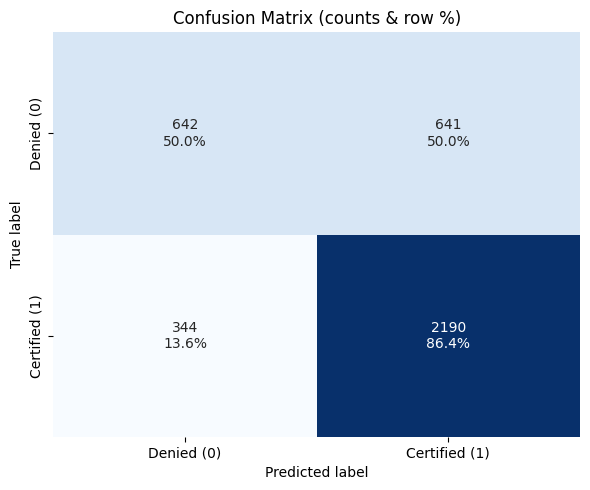

In [98]:
# ---- Final model selection ----
best_model = tuned_adb2   # AdaBoost tuned on original data

# ---- Test-set performance ----
best_model_test = model_performance_classification_sklearn(best_model, X_test, y_test)
print("Final model (AdaBoost on original data) – Test performance:")
display(best_model_test)

# ---- Confusion matrix on test set ----
confusion_matrix_sklearn(best_model, X_test, y_test)
plt.show()


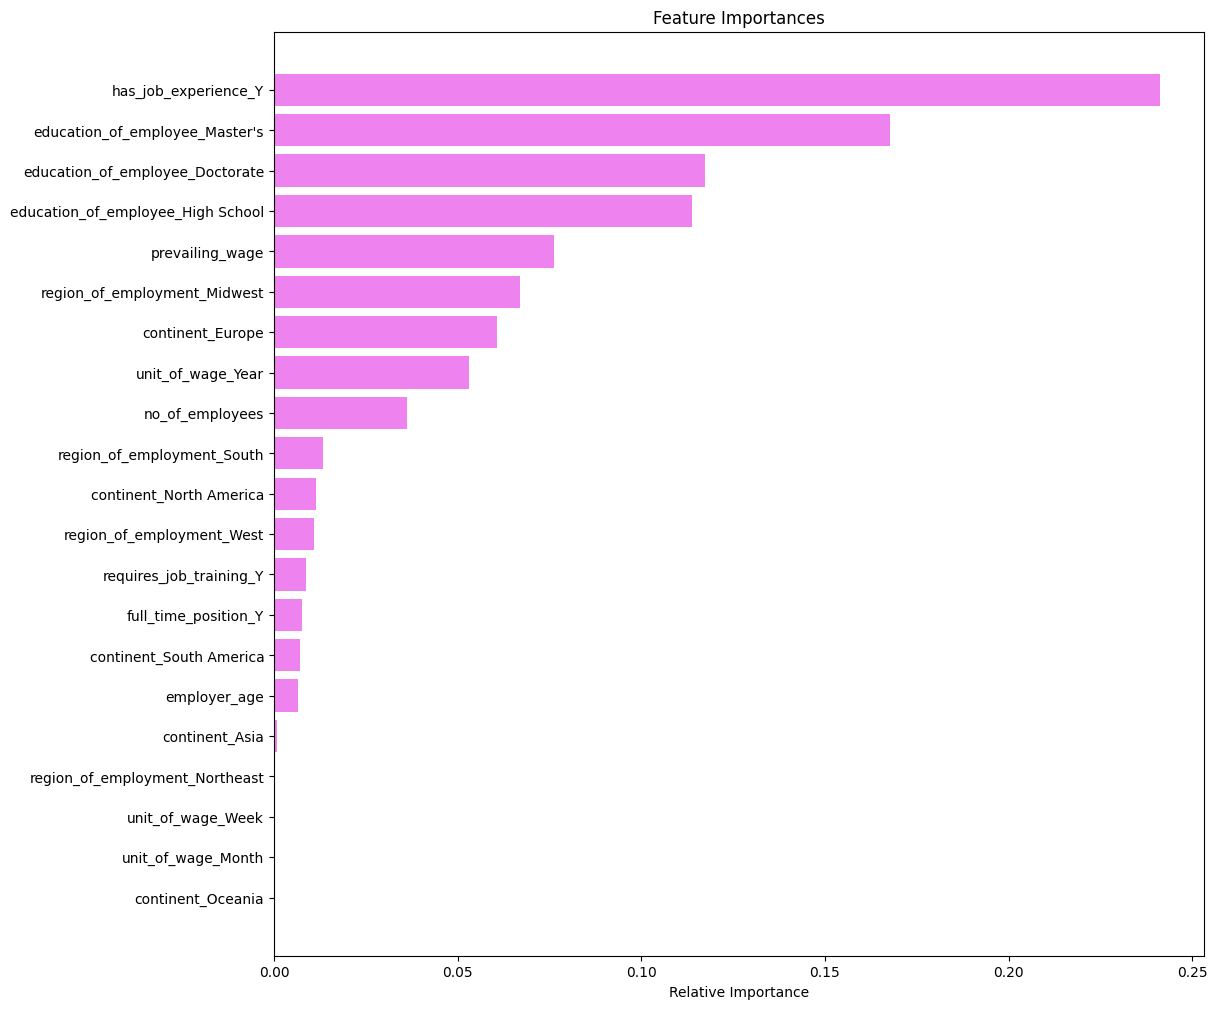

In [100]:
# import matplotlib.pyplot as plt
feature_names = X_train.columns
importances =  best_model.feature_importances_ ## Complete the code to check the feature importance of the best model
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()